# Import library

In [3]:
import os
import cv2
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

In [1]:
# Note
# Model detection terbaik -> few-shot medium k-40

# Single-stage

## Single modul segmentation

In [8]:
# --- 1. KONFIGURASI PATH ---
SUBSET = 'test' 

# [UPDATED] Mengarah ke folder Segmentation sesuai koreksi Anda
BASE_DATASET_PATH = Path("../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession")
IMAGE_DIR = BASE_DATASET_PATH / SUBSET / "images"

MODEL_PATH = Path("best_model/segmentation/single_module/leaf_and_lession.pt")
GT_CSV_PATH = Path(f"../ground_truth_experiment/results/{SUBSET}/csv/severity_results_{SUBSET}.csv")
GT_PLOT_DIR = Path(f"../ground_truth_experiment/results/{SUBSET}/severity_estimation_plot")

# Output
RESULT_BASE = Path(f"results/single_stage/single_module")
RESULT_CSV_DIR = RESULT_BASE / "csv"
RESULT_PLOT_DIR = RESULT_BASE / "plots"

os.makedirs(RESULT_CSV_DIR, exist_ok=True)
os.makedirs(RESULT_PLOT_DIR, exist_ok=True)

# Definisi Kelas
LEAF_CLASSES = [0, 2, 3] 
LESION_CLASSES = [1, 4]

def process_single_stage_single_module():
    print(f"--- START: Single-Stage Single-Module ({SUBSET}) ---")
    
    # 1. Load Data GT
    if not GT_CSV_PATH.exists():
        print(f"[FATAL] GT CSV tidak ada: {GT_CSV_PATH}")
        return
        
    gt_df = pd.read_csv(GT_CSV_PATH)
    gt_df['nama_file'] = gt_df['nama_file'].astype(str).str.strip()
    
    target_files = gt_df['nama_file'].tolist()
    gt_severity_map = pd.Series(gt_df.severity_estimation.values, index=gt_df.nama_file).to_dict()
    
    # 2. Cek Path Gambar
    if not IMAGE_DIR.exists():
        print(f"[FATAL] Folder gambar salah/tidak ditemukan: {IMAGE_DIR}")
        return

    # 3. Load Model
    try:
        model = YOLO(MODEL_PATH)
    except Exception as e:
        print(f"[FATAL] Gagal load model: {e}")
        return
    
    results_list = []
    visualization_count = 0
    MAX_VISUALIZATION = 5 
    
    stats = {"success": 0, "missing": 0, "no_mask": 0}

    # 4. Loop Processing
    for filename in tqdm(target_files, desc="Processing"):
        img_path = IMAGE_DIR / filename
        
        if not img_path.exists():
            stats["missing"] += 1
            continue
            
        # Inference
        try:
            results = model(str(img_path), verbose=False, conf=0.1)[0]
        except:
            continue
        
        leaf_area_px = 0
        lesion_area_px = 0
        severity = 0.0
        main_leaf_mask = None
        combined_lesion_mask = None
        
        # Load Original Image shape untuk referensi resize mask nanti
        # Kita baca pakai OpenCV untuk memastikan ukuran pixel akurat
        orig_img_cv = cv2.imread(str(img_path))
        if orig_img_cv is None: continue
        h_img, w_img = orig_img_cv.shape[:2]

        if results.masks is not None:
            masks = results.masks.data
            classes = results.boxes.cls
            
            # [PENTING] Resize mask ke ukuran asli gambar (h_img, w_img)
            # interpolate membutuhkan dimensi (N, C, H, W) -> unsqueeze(1)
            masks = torch.nn.functional.interpolate(masks.unsqueeze(1), size=(h_img, w_img), mode='nearest').squeeze(1)
            masks = masks.cpu().numpy().astype(np.uint8)
            classes = classes.cpu().numpy().astype(int)
            
            # Filter Class
            leaf_indices = [i for i, c in enumerate(classes) if c in LEAF_CLASSES]
            lesion_indices = [i for i, c in enumerate(classes) if c in LESION_CLASSES]
            
            if leaf_indices:
                # Cari Daun Terbesar
                leaf_areas = [np.sum(masks[i]) for i in leaf_indices]
                max_area_idx = np.argmax(leaf_areas)
                best_idx = leaf_indices[max_area_idx]
                
                main_leaf_mask = masks[best_idx]
                leaf_area_px = leaf_areas[max_area_idx]
                
                # Filter Lesi (Overlap dengan Main Leaf)
                if lesion_indices:
                    combined_lesion_mask = np.zeros((h_img, w_img), dtype=np.uint8)
                    for idx in lesion_indices:
                        curr_lesion_mask = masks[idx]
                        intersection = cv2.bitwise_and(curr_lesion_mask, curr_lesion_mask, mask=main_leaf_mask)
                        combined_lesion_mask = cv2.bitwise_or(combined_lesion_mask, intersection)
                    
                    lesion_area_px = np.sum(combined_lesion_mask)
                
                stats["success"] += 1
            else:
                stats["no_mask"] += 1
        else:
            stats["no_mask"] += 1

        # Hitung Severity
        if leaf_area_px > 0:
            severity = (lesion_area_px / leaf_area_px) * 100
            
        gt_sev_val = gt_severity_map.get(filename, "N/A")

        results_list.append({
            "nama_file": filename,
            "gt_severity": gt_sev_val,
            "pred_luas_daun": leaf_area_px,
            "pred_luas_lesi": lesion_area_px,
            "pred_severity": f"{severity:.2f}%"
        })
        
        # --- VISUALISASI ---
        if visualization_count < MAX_VISUALIZATION and leaf_area_px > 0:
            gt_plot_path = GT_PLOT_DIR / filename
            
            if gt_plot_path.exists():
                gt_img = cv2.imread(str(gt_plot_path))
                
                # Gunakan gambar yang sudah di-load sebelumnya (orig_img_cv)
                # Convert ke RGB untuk Matplotlib
                orig_vis = cv2.cvtColor(orig_img_cv, cv2.COLOR_BGR2RGB)
                
                if gt_img is not None:
                    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)
                    
                    # [PERBAIKAN] Overlay Mask pada Resolusi Asli
                    # Pastikan dimensi mask sama persis dengan image
                    if main_leaf_mask.shape != orig_vis.shape[:2]:
                         # Safety check: resize mask jika dimensi masih beda (jarang terjadi jika logic interpolate benar)
                         main_leaf_mask = cv2.resize(main_leaf_mask, (w_img, h_img), interpolation=cv2.INTER_NEAREST)
                         if combined_lesion_mask is not None:
                             combined_lesion_mask = cv2.resize(combined_lesion_mask, (w_img, h_img), interpolation=cv2.INTER_NEAREST)

                    overlay = orig_vis.copy()
                    
                    # Terapkan Warna
                    overlay[main_leaf_mask == 1] = [0, 255, 0] # Hijau
                    if combined_lesion_mask is not None:
                        overlay[combined_lesion_mask == 1] = [255, 0, 0] # Merah
                    
                    pred_vis = cv2.addWeighted(orig_vis, 0.6, overlay, 0.4, 0)
                    
                    # Plotting
                    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
                    
                    # Kiri: Ground Truth (Image Plot)
                    ax[0].imshow(gt_img)
                    ax[0].set_title(f"GT: {gt_sev_val}")
                    ax[0].axis('off')
                    
                    # Kanan: Prediction (High Res Image)
                    ax[1].imshow(pred_vis)
                    ax[1].set_title(f"Pred: {severity:.2f}%")
                    ax[1].axis('off')
                    
                    plt.savefig(RESULT_PLOT_DIR / f"cmp_{filename}", bbox_inches='tight')
                    plt.close(fig)
                    visualization_count += 1

    # Save CSV
    if results_list:
        df_res = pd.DataFrame(results_list)
        out_csv = RESULT_CSV_DIR / f"severity_prediction_{SUBSET}.csv"
        df_res.to_csv(out_csv, index=False)
        print(f"\n[DONE] CSV saved: {out_csv}")
        print(f"Stats: Success={stats['success']}, Missing={stats['missing']}, NoMask={stats['no_mask']}")
    else:
        print("[FAIL] Tidak ada data.")

if __name__ == "__main__":
    process_single_stage_single_module()

--- START: Single-Stage Single-Module (test) ---


Processing: 100%|██████████| 149/149 [00:34<00:00,  4.33it/s]


[DONE] CSV saved: results\single_stage\single_module\csv\severity_prediction_test.csv
Stats: Success=149, Missing=0, NoMask=0


## Dual modul segmentation

In [ ]:
# --- 1. KONFIGURASI PATH ---
SUBSET = 'test' 

# Path Dataset (Segmentation)
BASE_DATASET_PATH = Path("../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession")
IMAGE_DIR = BASE_DATASET_PATH / SUBSET / "images"

# Path Model Dual Module
MODEL_LEAF_PATH = Path("best_model/segmentation/dual_module/leaf.pt")
MODEL_LESION_PATH = Path("best_model/segmentation/dual_module/lession.pt")

# Path GT
GT_CSV_PATH = Path(f"../ground_truth_experiment/results/{SUBSET}/csv/severity_results_{SUBSET}.csv")
GT_PLOT_DIR = Path(f"../ground_truth_experiment/results/{SUBSET}/severity_estimation_plot")

# Output Directory
RESULT_BASE = Path(f"results/single_stage/dual_module")
RESULT_CSV_DIR = RESULT_BASE / "csv"
RESULT_PLOT_DIR = RESULT_BASE / "plots"

os.makedirs(RESULT_CSV_DIR, exist_ok=True)
os.makedirs(RESULT_PLOT_DIR, exist_ok=True)

# Definisi Kelas (Asumsi ID kelas tetap sama sesuai dataset original)
# Jika model dual module anda mereset class ID jadi 0 semua, code ini perlu disesuaikan.
# Namun biasanya jika split data roboflow, ID aslinya terbawa.
LEAF_CLASSES = [0, 2, 3] 
LESION_CLASSES = [1, 4]

def process_single_stage_dual_module():
    print(f"--- START: Single-Stage Dual-Module ({SUBSET}) ---")
    
    # 1. Cek File & Path
    if not IMAGE_DIR.exists():
        print(f"[FATAL] Folder gambar tidak ditemukan: {IMAGE_DIR}")
        return
    if not GT_CSV_PATH.exists():
        print(f"[FATAL] GT CSV tidak ditemukan.")
        return

    # 2. Load Models
    print("[INFO] Loading Models...")
    try:
        model_leaf = YOLO(MODEL_LEAF_PATH)
        model_lesion = YOLO(MODEL_LESION_PATH)
    except Exception as e:
        print(f"[FATAL] Gagal load model: {e}")
        return
    
    # 3. Load GT Data
    gt_df = pd.read_csv(GT_CSV_PATH)
    gt_df['nama_file'] = gt_df['nama_file'].astype(str).str.strip()
    target_files = gt_df['nama_file'].tolist()
    gt_severity_map = pd.Series(gt_df.severity_estimation.values, index=gt_df.nama_file).to_dict()
    
    results_list = []
    visualization_count = 0
    MAX_VISUALIZATION = 5 
    
    stats = {"success": 0, "missing": 0, "no_leaf": 0, "no_lesion": 0}

    # 4. Loop Processing
    for filename in tqdm(target_files, desc="Processing"):
        img_path = IMAGE_DIR / filename
        
        if not img_path.exists():
            stats["missing"] += 1
            continue
            
        # Load Original Image shape untuk referensi resize mask
        orig_img_cv = cv2.imread(str(img_path))
        if orig_img_cv is None: continue
        h_img, w_img = orig_img_cv.shape[:2]

        leaf_area_px = 0
        lesion_area_px = 0
        severity = 0.0
        main_leaf_mask = None
        combined_lesion_mask = None

        # --- STEP A: PREDICT LEAF (Model A) ---
        try:
            res_leaf = model_leaf(str(img_path), verbose=False, conf=0.1)[0]
        except: continue

        if res_leaf.masks is not None:
            masks_l = res_leaf.masks.data
            cls_l = res_leaf.boxes.cls
            
            # Resize mask leaf
            masks_l = torch.nn.functional.interpolate(masks_l.unsqueeze(1), size=(h_img, w_img), mode='nearest').squeeze(1)
            masks_l = masks_l.cpu().numpy().astype(np.uint8)
            cls_l = cls_l.cpu().numpy().astype(int)

            # Filter Leaf Classes
            leaf_indices = [i for i, c in enumerate(cls_l) if c in LEAF_CLASSES]
            
            # Jika tidak menemukan ID [0,2,3], coba ambil semua (antisipasi jika model mereset ID jadi 0)
            if not leaf_indices and len(cls_l) > 0:
                 # Fallback: Anggap semua output model leaf adalah daun
                 leaf_indices = range(len(cls_l))

            if leaf_indices:
                # Cari Daun Terbesar
                leaf_areas = [np.sum(masks_l[i]) for i in leaf_indices]
                max_area_idx = np.argmax(leaf_areas)
                best_idx = leaf_indices[max_area_idx]
                
                main_leaf_mask = masks_l[best_idx]
                leaf_area_px = leaf_areas[max_area_idx]
            else:
                stats["no_leaf"] += 1
        else:
            stats["no_leaf"] += 1

        # --- STEP B: PREDICT LESION (Model B) ---
        # Kita hanya lanjut prediksi lesi jika daun ditemukan
        if main_leaf_mask is not None:
            try:
                res_lesion = model_lesion(str(img_path), verbose=False, conf=0.1)[0]
            except: pass

            if res_lesion.masks is not None:
                masks_s = res_lesion.masks.data
                cls_s = res_lesion.boxes.cls
                
                # Resize mask lesion
                masks_s = torch.nn.functional.interpolate(masks_s.unsqueeze(1), size=(h_img, w_img), mode='nearest').squeeze(1)
                masks_s = masks_s.cpu().numpy().astype(np.uint8)
                cls_s = cls_s.cpu().numpy().astype(int)

                # Filter Lesion Classes
                lesion_indices = [i for i, c in enumerate(cls_s) if c in LESION_CLASSES]
                
                # Fallback jika model mereset ID
                if not lesion_indices and len(cls_s) > 0:
                    lesion_indices = range(len(cls_s))

                if lesion_indices:
                    combined_lesion_mask = np.zeros((h_img, w_img), dtype=np.uint8)
                    for idx in lesion_indices:
                        curr_lesion_mask = masks_s[idx]
                        # LOGIC PENGGABUNGAN (Overlap dengan Main Leaf dari Model A)
                        intersection = cv2.bitwise_and(curr_lesion_mask, curr_lesion_mask, mask=main_leaf_mask)
                        combined_lesion_mask = cv2.bitwise_or(combined_lesion_mask, intersection)
                    
                    lesion_area_px = np.sum(combined_lesion_mask)
                else:
                    stats["no_lesion"] += 1
            else:
                stats["no_lesion"] += 1
            
            stats["success"] += 1

        # Hitung Severity
        if leaf_area_px > 0:
            severity = (lesion_area_px / leaf_area_px) * 100
            
        gt_sev_val = gt_severity_map.get(filename, "N/A")

        results_list.append({
            "nama_file": filename,
            "gt_severity": gt_sev_val,
            "pred_luas_daun": leaf_area_px,
            "pred_luas_lesi": lesion_area_px,
            "pred_severity": f"{severity:.2f}%"
        })
        
        # --- VISUALISASI ---
        if visualization_count < MAX_VISUALIZATION and leaf_area_px > 0:
            gt_plot_path = GT_PLOT_DIR / filename
            
            if gt_plot_path.exists():
                gt_img = cv2.imread(str(gt_plot_path))
                orig_vis = cv2.cvtColor(orig_img_cv, cv2.COLOR_BGR2RGB) # Original High Res
                
                if gt_img is not None:
                    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)
                    
                    # Overlay Logic
                    overlay = orig_vis.copy()
                    
                    # Hijau (Mask dari Model A)
                    overlay[main_leaf_mask == 1] = [0, 255, 0] 
                    
                    # Merah (Mask dari Model B yang overlap)
                    if combined_lesion_mask is not None:
                        overlay[combined_lesion_mask == 1] = [255, 0, 0] 
                    
                    pred_vis = cv2.addWeighted(orig_vis, 0.6, overlay, 0.4, 0)
                    
                    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
                    ax[0].imshow(gt_img)
                    ax[0].set_title(f"GT: {gt_sev_val}")
                    ax[0].axis('off')
                    ax[1].imshow(pred_vis)
                    ax[1].set_title(f"Pred Dual-Mod: {severity:.2f}%")
                    ax[1].axis('off')
                    
                    plt.savefig(RESULT_PLOT_DIR / f"cmp_{filename}", bbox_inches='tight')
                    plt.close(fig)
                    visualization_count += 1

    # Save CSV
    if results_list:
        df_res = pd.DataFrame(results_list)
        out_csv = RESULT_CSV_DIR / f"severity_prediction_{SUBSET}.csv"
        df_res.to_csv(out_csv, index=False)
        print(f"\n[DONE] CSV saved: {out_csv}")
        print(f"Stats: Success={stats['success']}, Missing={stats['missing']}, NoLeaf={stats['no_leaf']}")
    else:
        print("[FAIL] Tidak ada data.")

if __name__ == "__main__":
    process_single_stage_dual_module()

--- START: Single-Stage Dual-Module (test) ---
[INFO] Loading Models...


Processing: 100%|██████████| 149/149 [00:42<00:00,  3.51it/s]


[DONE] CSV saved: results\single_stage\dual_module\csv\severity_prediction_test.csv
Stats: Success=149, Missing=0, NoLeaf=0


# Multi-stage

## Single modul segmentation

In [ ]:
# --- 1. KONFIGURASI PATH ---
SUBSET = 'test' 
BASE_DATASET_PATH = Path("../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession")
IMAGE_DIR = BASE_DATASET_PATH / SUBSET / "images"

# Models
MODEL_OD_PATH = Path("best_model/object_detection/best.pt")
MODEL_SEG_PATH = Path("best_model/segmentation/single_module/leaf_and_lession.pt")

# GT & Output
GT_CSV_PATH = Path(f"../ground_truth_experiment/results/{SUBSET}/csv/severity_results_{SUBSET}.csv")
GT_PLOT_DIR = Path(f"../ground_truth_experiment/results/{SUBSET}/severity_estimation_plot")
RESULT_BASE = Path(f"results/multi_stage/single_module_dynamic")
RESULT_CSV_DIR = RESULT_BASE / "csv"
RESULT_PLOT_DIR = RESULT_BASE / "plots"

os.makedirs(RESULT_CSV_DIR, exist_ok=True)
os.makedirs(RESULT_PLOT_DIR, exist_ok=True)

LEAF_CLASSES = [0, 2, 3] 
LESION_CLASSES = [1, 4]

# [SOLUSI BARU] Gunakan Rasio, bukan Pixel fix
# 0.3 artinya menambah luasan sebesar 30% dari ukuran box asli di setiap sisi
PADDING_RATIO = 0.3 

def process_multi_stage_single_module_dynamic():
    print(f"--- START: Multi-Stage Dynamic Padding ({SUBSET}) ---")
    
    # Load Models
    if not IMAGE_DIR.exists(): return
    try:
        model_od = YOLO(MODEL_OD_PATH)
        model_seg = YOLO(MODEL_SEG_PATH)
    except Exception as e:
        print(f"[FATAL] {e}")
        return
    
    # Load GT
    if not GT_CSV_PATH.exists(): return
    gt_df = pd.read_csv(GT_CSV_PATH)
    gt_df['nama_file'] = gt_df['nama_file'].astype(str).str.strip()
    target_files = gt_df['nama_file'].tolist()
    gt_severity_map = pd.Series(gt_df.severity_estimation.values, index=gt_df.nama_file).to_dict()
    
    results_list = []
    visualization_count = 0
    MAX_VISUALIZATION = 5 
    
    for filename in tqdm(target_files, desc="Processing"):
        img_path = IMAGE_DIR / filename
        if not img_path.exists(): continue
        
        orig_img_cv = cv2.imread(str(img_path))
        if orig_img_cv is None: continue
        h_orig, w_orig = orig_img_cv.shape[:2]

        leaf_area_px = 0
        lesion_area_px = 0
        severity = 0.0
        
        bbox_detected = None
        crop_mask_overlay = None
        crop_coords = None

        # --- STAGE 1: OD ---
        try:
            res_od = model_od(str(img_path), verbose=False, conf=0.25)[0]
        except: continue
        
        if len(res_od.boxes) > 0:
            areas = [(box[2]-box[0])*(box[3]-box[1]) for box in res_od.boxes.xyxy.cpu().numpy()]
            max_idx = np.argmax(areas)
            bx1, by1, bx2, by2 = res_od.boxes.xyxy.cpu().numpy()[max_idx].astype(int)
            
            bbox_detected = (bx1, by1, bx2, by2)
            
            # --- [LOGIC DYNAMIC PADDING] ---
            box_w = bx2 - bx1
            box_h = by2 - by1
            
            # Hitung padding berdasarkan persentase ukuran box
            pad_x = int(box_w * PADDING_RATIO)
            pad_y = int(box_h * PADDING_RATIO)
            
            # Terapkan padding
            x1 = max(0, bx1 - pad_x)
            y1 = max(0, by1 - pad_y)
            x2 = min(w_orig, bx2 + pad_x)
            y2 = min(h_orig, by2 + pad_y)
            
            crop_coords = (x1, y1, x2, y2)
            
            # --- CROP ---
            crop_img = orig_img_cv[y1:y2, x1:x2]
            h_crop, w_crop = crop_img.shape[:2]
            
            if h_crop > 0 and w_crop > 0:
                # --- STAGE 2: SEGMENTATION ---
                try:
                    res_seg = model_seg(crop_img, verbose=False, conf=0.1)[0]
                except: pass
                
                if res_seg.masks is not None:
                    # [PENTING] Gunakan masks.xy (Polygon)
                    polygons = res_seg.masks.xy
                    classes = res_seg.boxes.cls.cpu().numpy().astype(int)
                    
                    generated_masks = []
                    for polygon in polygons:
                        m = np.zeros((h_crop, w_crop), dtype=np.uint8)
                        if len(polygon) > 0:
                            pts = np.array([polygon], dtype=np.int32)
                            cv2.fillPoly(m, pts, 1)
                        generated_masks.append(m)
                    
                    # Filtering Logic
                    leaf_indices = [i for i, c in enumerate(classes) if c in LEAF_CLASSES]
                    lesion_indices = [i for i, c in enumerate(classes) if c in LESION_CLASSES]
                    
                    if leaf_indices:
                        leaf_areas = [np.sum(generated_masks[i]) for i in leaf_indices]
                        best_local_idx = np.argmax(leaf_areas)
                        best_idx = leaf_indices[best_local_idx]
                        
                        main_leaf_mask = generated_masks[best_idx]
                        leaf_area_px = leaf_areas[best_local_idx]
                        
                        combined_lesion_mask = np.zeros((h_crop, w_crop), dtype=np.uint8)
                        if lesion_indices:
                            for idx in lesion_indices:
                                curr = generated_masks[idx]
                                intersection = cv2.bitwise_and(curr, curr, mask=main_leaf_mask)
                                combined_lesion_mask = cv2.bitwise_or(combined_lesion_mask, intersection)
                            lesion_area_px = np.sum(combined_lesion_mask)
                        
                        # Vis Crop
                        crop_img_rgb = cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB)
                        overlay = crop_img_rgb.copy()
                        overlay[main_leaf_mask == 1] = [0, 255, 0]
                        if lesion_area_px > 0:
                            overlay[combined_lesion_mask == 1] = [255, 0, 0]
                        crop_mask_overlay = cv2.addWeighted(crop_img_rgb, 0.6, overlay, 0.4, 0)

        if leaf_area_px > 0:
            severity = (lesion_area_px / leaf_area_px) * 100
            
        gt_sev_val = gt_severity_map.get(filename, "N/A")

        results_list.append({
            "nama_file": filename,
            "gt_severity": gt_sev_val,
            "pred_luas_daun": leaf_area_px,
            "pred_luas_lesi": lesion_area_px,
            "pred_severity": f"{severity:.2f}%"
        })
        
        # --- VISUALISASI 3 PANEL (GT DI ATAS) ---
        if visualization_count < MAX_VISUALIZATION and leaf_area_px > 0:
            gt_plot_path = GT_PLOT_DIR / filename
            if gt_plot_path.exists():
                gt_img = cv2.imread(str(gt_plot_path))
                if gt_img is not None:
                    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)
                    orig_vis = cv2.cvtColor(orig_img_cv, cv2.COLOR_BGR2RGB)
                    
                    bx1, by1, bx2, by2 = bbox_detected
                    cx1, cy1, cx2, cy2 = crop_coords
                    
                    # Kotak Kuning = Box Asli
                    cv2.rectangle(orig_vis, (bx1, by1), (bx2, by2), (255, 255, 0), 6)
                    # Kotak Cyan = Area Crop (30% lebih besar)
                    cv2.rectangle(orig_vis, (cx1, cy1), (cx2, cy2), (0, 255, 255), 3)
                    
                    fig = plt.figure(figsize=(12, 12))
                    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])
                    
                    # Row 1: GT
                    ax1 = fig.add_subplot(gs[0, :]) 
                    ax1.imshow(gt_img)
                    ax1.set_title(f"GROUND TRUTH (Sev: {gt_sev_val})", fontsize=14, fontweight='bold', color='green')
                    ax1.axis('off')
                    
                    # Row 2 Left: OD
                    ax2 = fig.add_subplot(gs[1, 0])
                    ax2.imshow(orig_vis)
                    ax2.set_title("STAGE 1: Dynamic Padding (+30%)", fontsize=12, fontweight='bold')
                    ax2.axis('off')
                    
                    # Row 2 Right: Seg
                    ax3 = fig.add_subplot(gs[1, 1])
                    if crop_mask_overlay is not None:
                        ax3.imshow(crop_mask_overlay)
                        ax3.set_title(f"STAGE 2: Seg on Crop\n(Pred Sev: {severity:.2f}%)", fontsize=12, fontweight='bold')
                    else:
                        ax3.text(0.5, 0.5, "No Mask", ha='center')
                    ax3.axis('off')
                    
                    plt.tight_layout()
                    plt.savefig(RESULT_PLOT_DIR / f"cmp_{filename}", bbox_inches='tight')
                    plt.close(fig)
                    visualization_count += 1

    if results_list:
        df_res = pd.DataFrame(results_list)
        out_csv = RESULT_CSV_DIR / f"severity_prediction_{SUBSET}.csv"
        df_res.to_csv(out_csv, index=False)
        print(f"\n[DONE] CSV saved: {out_csv}")
    else:
        print("[FAIL] Tidak ada data.")

if __name__ == "__main__":
    process_multi_stage_single_module_dynamic()

--- START: Multi-Stage Dynamic Padding (test) ---


Processing: 100%|██████████| 149/149 [00:46<00:00,  3.18it/s]


[DONE] CSV saved: results\multi_stage\single_module_dynamic\csv\severity_prediction_test.csv


## Dual modul segmentation

In [ ]:
# --- 1. KONFIGURASI PATH ---
SUBSET = 'test' 
BASE_DATASET_PATH = Path("../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession")
IMAGE_DIR = BASE_DATASET_PATH / SUBSET / "images"

# --- MODELS (TOTAL 3 MODEL) ---
MODEL_OD_PATH = Path("best_model/object_detection/best.pt")               # Stage 1: Deteksi
MODEL_SEG_LEAF_PATH = Path("best_model/segmentation/dual_module/leaf.pt")       # Stage 2A: Segmentasi Daun
MODEL_SEG_LESION_PATH = Path("best_model/segmentation/dual_module/lession.pt")  # Stage 2B: Segmentasi Lesi

# GT & Output
GT_CSV_PATH = Path(f"../ground_truth_experiment/results/{SUBSET}/csv/severity_results_{SUBSET}.csv")
GT_PLOT_DIR = Path(f"../ground_truth_experiment/results/{SUBSET}/severity_estimation_plot")

RESULT_BASE = Path(f"results/multi_stage/dual_module_dynamic")
RESULT_CSV_DIR = RESULT_BASE / "csv"
RESULT_PLOT_DIR = RESULT_BASE / "plots"

os.makedirs(RESULT_CSV_DIR, exist_ok=True)
os.makedirs(RESULT_PLOT_DIR, exist_ok=True)

# Class IDs
LEAF_CLASSES = [0, 2, 3] 
LESION_CLASSES = [1, 4]

# Konfigurasi Padding (30%)
PADDING_RATIO = 0.3 

def process_multi_stage_dual_module_dynamic():
    print(f"--- START: Multi-Stage Dual-Module Dynamic ({SUBSET}) ---")
    
    # 1. Load Models
    if not IMAGE_DIR.exists(): return
    try:
        model_od = YOLO(MODEL_OD_PATH)
        model_leaf = YOLO(MODEL_SEG_LEAF_PATH)
        model_lesion = YOLO(MODEL_SEG_LESION_PATH)
    except Exception as e:
        print(f"[FATAL] Gagal load model: {e}")
        return
    
    # 2. Load GT
    if not GT_CSV_PATH.exists(): return
    gt_df = pd.read_csv(GT_CSV_PATH)
    gt_df['nama_file'] = gt_df['nama_file'].astype(str).str.strip()
    target_files = gt_df['nama_file'].tolist()
    gt_severity_map = pd.Series(gt_df.severity_estimation.values, index=gt_df.nama_file).to_dict()
    
    results_list = []
    visualization_count = 0
    MAX_VISUALIZATION = 5 
    
    for filename in tqdm(target_files, desc="Processing"):
        img_path = IMAGE_DIR / filename
        if not img_path.exists(): continue
        
        orig_img_cv = cv2.imread(str(img_path))
        if orig_img_cv is None: continue
        h_orig, w_orig = orig_img_cv.shape[:2]

        leaf_area_px = 0
        lesion_area_px = 0
        severity = 0.0
        
        # Variabel Visualisasi
        bbox_detected = None
        crop_coords = None
        crop_mask_overlay = None

        # --- STAGE 1: OBJECT DETECTION ---
        try:
            res_od = model_od(str(img_path), verbose=False, conf=0.25)[0]
        except: continue
        
        if len(res_od.boxes) > 0:
            # Cari box terbesar
            areas = [(box[2]-box[0])*(box[3]-box[1]) for box in res_od.boxes.xyxy.cpu().numpy()]
            max_idx = np.argmax(areas)
            bx1, by1, bx2, by2 = res_od.boxes.xyxy.cpu().numpy()[max_idx].astype(int)
            
            bbox_detected = (bx1, by1, bx2, by2)
            
            # --- DYNAMIC PADDING ---
            box_w = bx2 - bx1
            box_h = by2 - by1
            pad_x = int(box_w * PADDING_RATIO)
            pad_y = int(box_h * PADDING_RATIO)
            
            x1 = max(0, bx1 - pad_x)
            y1 = max(0, by1 - pad_y)
            x2 = min(w_orig, bx2 + pad_x)
            y2 = min(h_orig, by2 + pad_y)
            
            crop_coords = (x1, y1, x2, y2)
            
            # --- CROP ---
            crop_img = orig_img_cv[y1:y2, x1:x2]
            h_crop, w_crop = crop_img.shape[:2]
            
            if h_crop > 0 and w_crop > 0:
                main_leaf_mask = None
                combined_lesion_mask = None
                
                # --- STAGE 2A: SEGMENTATION LEAF (Model A) ---
                try:
                    res_leaf = model_leaf(crop_img, verbose=False, conf=0.1)[0]
                except: pass
                
                if res_leaf.masks is not None:
                    # Extract Polygons (Anti-Cutoff)
                    polygons = res_leaf.masks.xy
                    classes = res_leaf.boxes.cls.cpu().numpy().astype(int)
                    
                    gen_masks_leaf = []
                    for polygon in polygons:
                        m = np.zeros((h_crop, w_crop), dtype=np.uint8)
                        if len(polygon) > 0:
                            pts = np.array([polygon], dtype=np.int32)
                            cv2.fillPoly(m, pts, 1)
                        gen_masks_leaf.append(m)
                    
                    # Filter Leaf Classes (Fallback logic included)
                    leaf_indices = [i for i, c in enumerate(classes) if c in LEAF_CLASSES]
                    if not leaf_indices and len(classes) > 0: leaf_indices = range(len(classes))

                    if leaf_indices:
                        leaf_areas = [np.sum(gen_masks_leaf[i]) for i in leaf_indices]
                        best_local_idx = np.argmax(leaf_areas)
                        best_idx = leaf_indices[best_local_idx]
                        
                        main_leaf_mask = gen_masks_leaf[best_idx]
                        leaf_area_px = leaf_areas[best_local_idx]

                # --- STAGE 2B: SEGMENTATION LESION (Model B) ---
                # Hanya jalankan jika daun ditemukan di Stage 2A
                if main_leaf_mask is not None:
                    try:
                        res_lesion = model_lesion(crop_img, verbose=False, conf=0.1)[0]
                    except: pass
                    
                    if res_lesion.masks is not None:
                        polygons_s = res_lesion.masks.xy
                        classes_s = res_lesion.boxes.cls.cpu().numpy().astype(int)
                        
                        gen_masks_lesion = []
                        for polygon in polygons_s:
                            m = np.zeros((h_crop, w_crop), dtype=np.uint8)
                            if len(polygon) > 0:
                                pts = np.array([polygon], dtype=np.int32)
                                cv2.fillPoly(m, pts, 1)
                            gen_masks_lesion.append(m)
                        
                        # Filter Lesion Classes (Fallback logic included)
                        lesion_indices = [i for i, c in enumerate(classes_s) if c in LESION_CLASSES]
                        if not lesion_indices and len(classes_s) > 0: lesion_indices = range(len(classes_s))

                        if lesion_indices:
                            combined_lesion_mask = np.zeros((h_crop, w_crop), dtype=np.uint8)
                            for idx in lesion_indices:
                                curr = gen_masks_lesion[idx]
                                # Cross-Model Intersection
                                intersect = cv2.bitwise_and(curr, curr, mask=main_leaf_mask)
                                combined_lesion_mask = cv2.bitwise_or(combined_lesion_mask, intersect)
                            
                            lesion_area_px = np.sum(combined_lesion_mask)
                
                # --- VISUALISASI OVERLAY ---
                if main_leaf_mask is not None:
                    crop_img_rgb = cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB)
                    overlay = crop_img_rgb.copy()
                    
                    # Hijau (Leaf Model A)
                    overlay[main_leaf_mask == 1] = [0, 255, 0]
                    # Merah (Lesion Model B)
                    if lesion_area_px > 0:
                         overlay[combined_lesion_mask == 1] = [255, 0, 0]
                    
                    crop_mask_overlay = cv2.addWeighted(crop_img_rgb, 0.6, overlay, 0.4, 0)

        # Hitung Severity
        if leaf_area_px > 0:
            severity = (lesion_area_px / leaf_area_px) * 100
            
        gt_sev_val = gt_severity_map.get(filename, "N/A")

        results_list.append({
            "nama_file": filename,
            "gt_severity": gt_sev_val,
            "pred_luas_daun": leaf_area_px,
            "pred_luas_lesi": lesion_area_px,
            "pred_severity": f"{severity:.2f}%"
        })
        
        # --- PLOTTING 3 PANEL (GT DI ATAS) ---
        if visualization_count < MAX_VISUALIZATION and leaf_area_px > 0:
            gt_plot_path = GT_PLOT_DIR / filename
            if gt_plot_path.exists():
                gt_img = cv2.imread(str(gt_plot_path))
                if gt_img is not None:
                    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)
                    orig_vis = cv2.cvtColor(orig_img_cv, cv2.COLOR_BGR2RGB)
                    
                    # Gambar Kotak Stage 1
                    bx1, by1, bx2, by2 = bbox_detected
                    cx1, cy1, cx2, cy2 = crop_coords
                    
                    # Kuning: Box OD Asli
                    cv2.rectangle(orig_vis, (bx1, by1), (bx2, by2), (255, 255, 0), 6)
                    # Cyan: Box Crop (Padding)
                    cv2.rectangle(orig_vis, (cx1, cy1), (cx2, cy2), (0, 255, 255), 3)
                    
                    # Grid Layout
                    fig = plt.figure(figsize=(12, 12))
                    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])
                    
                    # Baris 1: GT
                    ax1 = fig.add_subplot(gs[0, :]) 
                    ax1.imshow(gt_img)
                    ax1.set_title(f"GROUND TRUTH (Sev: {gt_sev_val})", fontsize=14, fontweight='bold', color='green')
                    ax1.axis('off')
                    
                    # Baris 2 Kiri: Stage 1
                    ax2 = fig.add_subplot(gs[1, 0])
                    ax2.imshow(orig_vis)
                    ax2.set_title("STAGE 1: Dynamic Padding (+30%)", fontsize=12, fontweight='bold')
                    ax2.axis('off')
                    
                    # Baris 2 Kanan: Stage 2 (Dual Model)
                    ax3 = fig.add_subplot(gs[1, 1])
                    if crop_mask_overlay is not None:
                        ax3.imshow(crop_mask_overlay)
                        ax3.set_title(f"STAGE 2: Dual Seg on Crop\n(Pred Sev: {severity:.2f}%)", fontsize=12, fontweight='bold')
                    else:
                        ax3.text(0.5, 0.5, "No Mask", ha='center')
                    ax3.axis('off')
                    
                    plt.tight_layout()
                    plt.savefig(RESULT_PLOT_DIR / f"cmp_{filename}", bbox_inches='tight')
                    plt.close(fig)
                    visualization_count += 1

    if results_list:
        df_res = pd.DataFrame(results_list)
        out_csv = RESULT_CSV_DIR / f"severity_prediction_{SUBSET}.csv"
        df_res.to_csv(out_csv, index=False)
        print(f"\n[DONE] CSV saved: {out_csv}")
    else:
        print("[FAIL] Tidak ada data.")

if __name__ == "__main__":
    process_multi_stage_dual_module_dynamic()

--- START: Multi-Stage Dual-Module Dynamic (test) ---


Processing: 100%|██████████| 149/149 [01:17<00:00,  1.93it/s]


[DONE] CSV saved: results\multi_stage\dual_module_dynamic\csv\severity_prediction_test.csv


# Comparison MAE GT vs Single vs Multi

## Visualization GT, Single, Multi

In [4]:
# --- 1. KONFIGURASI PATH ---
SUBSET = 'test' 
GT_CSV_PATH = Path(f"../ground_truth_experiment/results/{SUBSET}/csv/severity_results_{SUBSET}.csv")

# Path ke Folder PLOTS hasil run sebelumnya
# Pastikan nama folder sesuai dengan yang ada di komputer Anda
PATHS = {
    "Single-Stage Single-Module": Path("results/single_stage/single_module/plots"),
    "Single-Stage Dual-Module":   Path("results/single_stage/dual_module/plots"),
    "Multi-Stage Single-Module":  Path("results/multi_stage/single_module_dynamic/plots"),
    "Multi-Stage Dual-Module":    Path("results/multi_stage/dual_module_dynamic/plots")
}

# Output
OUTPUT_DIR = Path("results/global_comparison_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def create_global_comparison():
    print("--- START: Global Comparison Visualization ---")
    
    # 1. Load Daftar File dari GT
    if not GT_CSV_PATH.exists():
        print("[FATAL] GT CSV tidak ditemukan.")
        return

    gt_df = pd.read_csv(GT_CSV_PATH)
    gt_df['nama_file'] = gt_df['nama_file'].astype(str).str.strip()
    target_files = gt_df['nama_file'].tolist()
    
    # Ambil 5 sampel saja (atau hapus slicing [:5] untuk semua gambar)
    target_files = target_files[:5]
    
    for filename in tqdm(target_files, desc="Generating Global Plots"):
        # Nama file plot biasanya diawali "cmp_" atau "comparison_" sesuai kode sebelumnya
        # Kita perlu mencari file yang mengandung nama filename asli di setiap folder
        
        images = {}
        
        for scheme_name, folder_path in PATHS.items():
            # Cari file gambar di folder tersebut yang mengandung filename
            # Pola file output kita sebelumnya: "cmp_{filename}" atau "comparison_{filename}"
            found_path = None
            
            # Coba cari pola yang mungkin
            candidates = [
                folder_path / f"cmp_{filename}",
                folder_path / f"comparison_{filename}",
                folder_path / filename # Jaga-jaga jika disimpan tanpa prefix
            ]
            
            for p in candidates:
                if p.exists():
                    found_path = p
                    break
            
            if found_path:
                img = cv2.imread(str(found_path))
                if img is not None:
                    images[scheme_name] = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                else:
                    images[scheme_name] = None
            else:
                images[scheme_name] = None

        # --- PLOTTING GRID 2x2 ---
        fig, axes = plt.subplots(2, 2, figsize=(20, 16))
        fig.suptitle(f"Global Comparison: {filename}", fontsize=20, fontweight='bold', y=0.95)
        
        # Flatten axes array for easy iteration
        ax_flat = axes.flatten()
        
        scheme_order = [
            "Single-Stage Single-Module", "Single-Stage Dual-Module",
            "Multi-Stage Single-Module",  "Multi-Stage Dual-Module"
        ]
        
        for i, scheme in enumerate(scheme_order):
            ax = ax_flat[i]
            img = images.get(scheme)
            
            if img is not None:
                ax.imshow(img)
                ax.set_title(scheme, fontsize=14, fontweight='bold', pad=10, 
                             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))
            else:
                # Jika gambar tidak ditemukan (misal missing bbox)
                ax.text(0.5, 0.5, "Result Not Available\n(Missing/Failed)", 
                        ha='center', va='center', fontsize=12, color='red')
                ax.set_title(scheme, fontsize=14, fontweight='bold')
                
            ax.axis('off')
            
            # Tambahkan border tipis pada subplot
            for spine in ax.spines.values():
                spine.set_edgecolor('gray')
                spine.set_linewidth(1)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        out_path = OUTPUT_DIR / f"global_cmp_{filename}"
        plt.savefig(out_path, bbox_inches='tight', dpi=100)
        plt.close(fig)

    print(f"\n[DONE] Global comparison plots saved to: {OUTPUT_DIR}")

if __name__ == "__main__":
    create_global_comparison()

--- START: Global Comparison Visualization ---


Generating Global Plots:   0%|          | 0/5 [00:00<?, ?it/s]

Generating Global Plots: 100%|██████████| 5/5 [00:02<00:00,  2.24it/s]


[DONE] Global comparison plots saved to: results\global_comparison_plots


In [11]:
# --- 1. CONFIGURATION ---
SUBSET = 'test' 
BASE_DATASET_PATH = Path("../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession")
IMAGE_DIR = BASE_DATASET_PATH / SUBSET / "images"
GT_CSV_PATH = Path(f"../ground_truth_experiment/results/{SUBSET}/csv/severity_results_{SUBSET}.csv")

# Model Paths
MODEL_OD_PATH = Path("best_model/object_detection/best.pt")
MODEL_SEG_SINGLE_PATH = Path("best_model/segmentation/single_module/leaf_and_lession.pt")
MODEL_SEG_LEAF_PATH = Path("best_model/segmentation/dual_module/leaf.pt")
MODEL_SEG_LESION_PATH = Path("best_model/segmentation/dual_module/lession.pt")

OUTPUT_DIR = Path("results/final_live_inference")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Classes & Config
LEAF_CLASSES = [0, 2, 3] 
LESION_CLASSES = [1, 4]
PADDING_RATIO = 0.3 # 30% Padding

# --- 2. HELPER FUNCTIONS ---

def parse_percent(x):
    if isinstance(x, str):
        return float(x.replace('%', '').strip())
    return float(x) if x is not None else 0.0

def calculate_severity_from_masks(h, w, masks_data, classes_data):
    """
    Menghitung severity dan mengembalikan Mask Daun (Hijau) & Lesi (Merah)
    menggunakan logika Polygon (masks.xy) agar tidak terpotong.
    """
    # Reconstruct masks from polygons
    generated_masks = []
    if masks_data is not None:
        polygons = masks_data.xy
        for polygon in polygons:
            m = np.zeros((h, w), dtype=np.uint8)
            if len(polygon) > 0:
                pts = np.array([polygon], dtype=np.int32)
                cv2.fillPoly(m, pts, 1)
            generated_masks.append(m)
    
    leaf_area = 0
    lesion_area = 0
    main_leaf_mask = None
    combined_lesion_mask = None
    
    if generated_masks:
        leaf_indices = [i for i, c in enumerate(classes_data) if c in LEAF_CLASSES]
        lesion_indices = [i for i, c in enumerate(classes_data) if c in LESION_CLASSES]
        
        # 1. Find Main Leaf
        if leaf_indices:
            leaf_areas = [np.sum(generated_masks[i]) for i in leaf_indices]
            best_idx = leaf_indices[np.argmax(leaf_areas)]
            main_leaf_mask = generated_masks[best_idx]
            leaf_area = np.sum(main_leaf_mask)
            
            # 2. Find Lesions inside Leaf
            if lesion_indices:
                combined_lesion_mask = np.zeros((h, w), dtype=np.uint8)
                for idx in lesion_indices:
                    curr = generated_masks[idx]
                    intersect = cv2.bitwise_and(curr, curr, mask=main_leaf_mask)
                    combined_lesion_mask = cv2.bitwise_or(combined_lesion_mask, intersect)
                lesion_area = np.sum(combined_lesion_mask)

    severity = (lesion_area / leaf_area * 100) if leaf_area > 0 else 0.0
    return severity, main_leaf_mask, combined_lesion_mask

def draw_overlay(img, leaf_mask, lesion_mask):
    """Helper untuk menggambar mask hijau/merah ke gambar"""
    vis = img.copy()
    overlay = img.copy()
    
    if leaf_mask is not None:
        overlay[leaf_mask == 1] = [0, 255, 0] # Green
    if lesion_mask is not None:
        overlay[lesion_mask == 1] = [255, 0, 0] # Red
        
    return cv2.addWeighted(vis, 0.6, overlay, 0.4, 0)

# --- 3. PIPELINE FUNCTIONS (Live Inference) ---

def run_single_stage_single(img, model):
    h, w = img.shape[:2]
    res = model(img, verbose=False, conf=0.1)[0]
    
    if res.masks is None: return img, 0.0
    
    sev, leaf_m, lesion_m = calculate_severity_from_masks(h, w, res.masks, res.boxes.cls.cpu().numpy())
    final_img = draw_overlay(img, leaf_m, lesion_m)
    return final_img, sev

def run_single_stage_dual(img, model_leaf, model_lesion):
    h, w = img.shape[:2]
    
    # Model Leaf
    res_l = model_leaf(img, verbose=False, conf=0.1)[0]
    main_leaf_mask = None
    leaf_area = 0
    
    if res_l.masks is not None:
        # Extract Leaf Polygon
        polygons = res_l.masks.xy
        cls_l = res_l.boxes.cls.cpu().numpy()
        gen_masks = []
        for p in polygons:
            m = np.zeros((h, w), dtype=np.uint8)
            if len(p)>0: cv2.fillPoly(m, np.array([p], dtype=np.int32), 1)
            gen_masks.append(m)
            
        leaf_idxs = [i for i,c in enumerate(cls_l) if c in LEAF_CLASSES]
        if not leaf_idxs and len(cls_l)>0: leaf_idxs = range(len(cls_l)) # Fallback
        
        if leaf_idxs:
            areas = [np.sum(gen_masks[i]) for i in leaf_idxs]
            main_leaf_mask = gen_masks[leaf_idxs[np.argmax(areas)]]
            leaf_area = np.sum(main_leaf_mask)

    # Model Lesion
    combined_lesion_mask = None
    lesion_area = 0
    
    if main_leaf_mask is not None:
        res_s = model_lesion(img, verbose=False, conf=0.1)[0]
        if res_s.masks is not None:
            polygons = res_s.masks.xy
            cls_s = res_s.boxes.cls.cpu().numpy()
            gen_masks = []
            for p in polygons:
                m = np.zeros((h, w), dtype=np.uint8)
                if len(p)>0: cv2.fillPoly(m, np.array([p], dtype=np.int32), 1)
                gen_masks.append(m)

            lesion_idxs = [i for i,c in enumerate(cls_s) if c in LESION_CLASSES]
            if not lesion_idxs and len(cls_s)>0: lesion_idxs = range(len(cls_s))
            
            if lesion_idxs:
                combined_lesion_mask = np.zeros((h, w), dtype=np.uint8)
                for i in lesion_idxs:
                    inter = cv2.bitwise_and(gen_masks[i], gen_masks[i], mask=main_leaf_mask)
                    combined_lesion_mask = cv2.bitwise_or(combined_lesion_mask, inter)
                lesion_area = np.sum(combined_lesion_mask)

    severity = (lesion_area/leaf_area*100) if leaf_area > 0 else 0.0
    final_img = draw_overlay(img, main_leaf_mask, combined_lesion_mask)
    return final_img, severity

def get_crop(img, model_od):
    h, w = img.shape[:2]
    res_od = model_od(img, verbose=False, conf=0.25)[0]
    
    if len(res_od.boxes) == 0: return None
    
    areas = [(b[2]-b[0])*(b[3]-b[1]) for b in res_od.boxes.xyxy.cpu().numpy()]
    bx1, by1, bx2, by2 = res_od.boxes.xyxy.cpu().numpy()[np.argmax(areas)].astype(int)
    
    pad_x = int((bx2-bx1) * PADDING_RATIO)
    pad_y = int((by2-by1) * PADDING_RATIO)
    
    x1, y1 = max(0, bx1-pad_x), max(0, by1-pad_y)
    x2, y2 = min(w, bx2+pad_x), min(h, by2+pad_y)
    
    return img[y1:y2, x1:x2]

def run_multi_stage_single(img, model_od, model_seg):
    crop = get_crop(img, model_od)
    if crop is None: return img, 0.0 # Return full img if detect fail
    
    # Run seg on crop
    return run_single_stage_single(crop, model_seg)

def run_multi_stage_dual(img, model_od, model_leaf, model_lesion):
    crop = get_crop(img, model_od)
    if crop is None: return img, 0.0
    
    # Run dual seg on crop
    return run_single_stage_dual(crop, model_leaf, model_lesion)

# --- 4. MAIN EXECUTION ---

def main():
    print("--- Loading Models... ---")
    model_od = YOLO(MODEL_OD_PATH)
    model_ss = YOLO(MODEL_SEG_SINGLE_PATH)
    model_dl = YOLO(MODEL_SEG_LEAF_PATH)
    model_ds = YOLO(MODEL_SEG_LESION_PATH)
    
    # Load GT
    gt_df = pd.read_csv(GT_CSV_PATH)
    gt_df['nama_file'] = gt_df['nama_file'].astype(str).str.strip()
    
    # Select Files
    categories = {
        "Frog Eye Leaf Spot": "frog_eye_leaf_spot",
        "Healthy": "healthy",
        "Rust": "rust"
    }
    
    selected_files = []
    print("\n--- Selecting Random Files ---")
    for label, keyword in categories.items():
        candidates = gt_df[gt_df['nama_file'].str.contains(keyword, case=False)]
        if not candidates.empty:
            chosen = candidates.sample(1).iloc[0]
            selected_files.append(chosen)
            print(f"[{label}] -> {chosen['nama_file']}")
            
    # Process
    for item in selected_files:
        filename = item['nama_file']
        gt_sev_val = parse_percent(item['severity_estimation'])
        img_path = IMAGE_DIR / filename
        
        if not img_path.exists(): continue
        
        orig_img = cv2.imread(str(img_path))
        orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
        
        # --- RUN 4 SCHEMES LIVE ---
        results = {}
        
        # 1. SS-SM
        vis1, sev1 = run_single_stage_single(orig_img_rgb.copy(), model_ss)
        results["Single-Stage\nSingle-Module"] = (vis1, sev1)
        
        # 2. SS-DM
        vis2, sev2 = run_single_stage_dual(orig_img_rgb.copy(), model_dl, model_ds)
        results["Single-Stage\nDual-Module"] = (vis2, sev2)
        
        # 3. MS-SM
        vis3, sev3 = run_multi_stage_single(orig_img_rgb.copy(), model_od, model_ss)
        results["Multi-Stage\nSingle-Module"] = (vis3, sev3)
        
        # 4. MS-DM
        vis4, sev4 = run_multi_stage_dual(orig_img_rgb.copy(), model_od, model_dl, model_ds)
        results["Multi-Stage\nDual-Module"] = (vis4, sev4)
        
        # --- PLOTTING ---
        fig, axes = plt.subplots(2, 2, figsize=(16, 16))
        plt.subplots_adjust(wspace=0.1, hspace=0.2)
        flat_axes = axes.flatten()
        
        for i, (name, (vis, pred_sev)) in enumerate(results.items()):
            ax = flat_axes[i]
            
            # Show Image
            ax.imshow(vis)
            
            # Calculate Diff
            diff = abs(pred_sev - gt_sev_val)
            
            # Title
            title_text = (f"{name}\n"
                          f"Sev: {pred_sev:.2f}% (GT: {gt_sev_val:.2f}%)\n"
                          f"Diff: {diff:.2f}%")
            
            ax.set_title(title_text, fontsize=14, fontweight='bold', pad=10)
            ax.axis('off')
            
        out_file = OUTPUT_DIR / filename
        plt.savefig(out_file, bbox_inches='tight', dpi=150)
        plt.close(fig)
        print(f"Saved: {out_file}")

    print(f"\n[DONE] All images saved to: {OUTPUT_DIR}")

if __name__ == "__main__":
    main()

--- Loading Models... ---

--- Selecting Random Files ---
[Frog Eye Leaf Spot] -> 03522_frog_eye_leaf_spot_jpg.rf.027da5216284a9bfd10315c2dee6fedd.jpg
[Healthy] -> 08099_healthy_jpg.rf.ec9f9b1d6b1ccfee07cc505c5360d9ef.jpg
[Rust] -> 10699_rust_jpg.rf.6ec854eb6df11bcb6112362035afd3f4.jpg
Saved: results\final_live_inference\03522_frog_eye_leaf_spot_jpg.rf.027da5216284a9bfd10315c2dee6fedd.jpg
Saved: results\final_live_inference\08099_healthy_jpg.rf.ec9f9b1d6b1ccfee07cc505c5360d9ef.jpg
Saved: results\final_live_inference\10699_rust_jpg.rf.6ec854eb6df11bcb6112362035afd3f4.jpg

[DONE] All images saved to: results\final_live_inference


## Graph GT, Single-stage, Multi-stage

--- START: MAE Comparison (test) ---
> Single-Stage Single-Module: MAE = 1.4882%
> Single-Stage Dual-Module: MAE = 0.3897%
> Multi-Stage Single-Module: MAE = 0.6603%
> Multi-Stage Dual-Module: MAE = 0.4823%


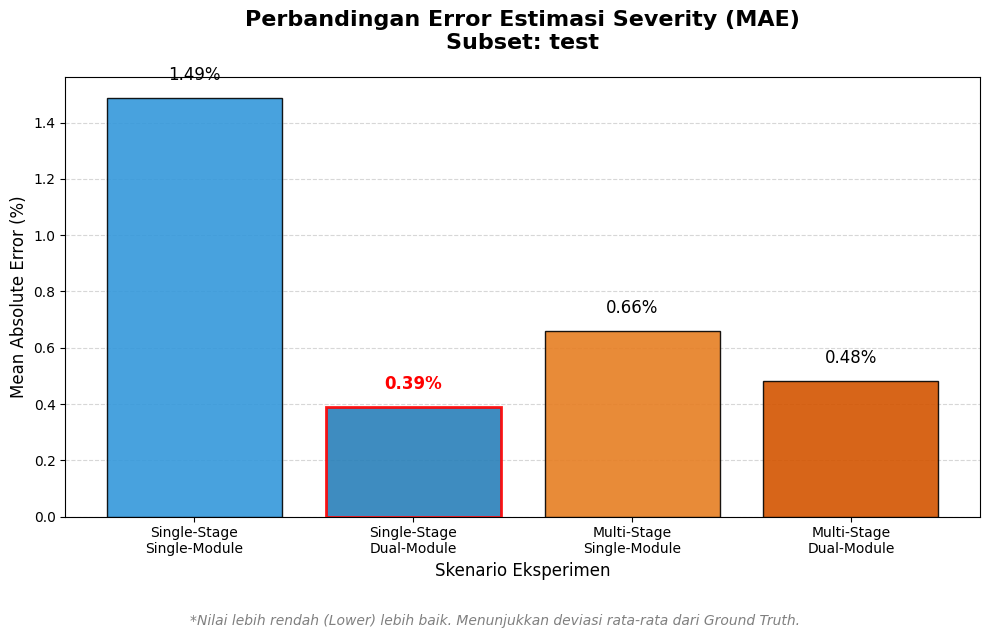


Grafik perbandingan tersimpan di: results\mae_comparison_chart_test.png


In [ ]:
# --- 1. KONFIGURASI PATH HASIL ---
# Sesuaikan subset jika Anda menggunakan train/valid
SUBSET = 'test' 

# Path CSV dari 4 Skenario Eksperimen
# Pastikan path ini sesuai dengan output kode-kode sebelumnya
FILES = {
    "Single-Stage\nSingle-Module": Path(f"results/single_stage/single_module/csv/severity_prediction_{SUBSET}.csv"),
    "Single-Stage\nDual-Module":   Path(f"results/single_stage/dual_module/csv/severity_prediction_{SUBSET}.csv"),
    "Multi-Stage\nSingle-Module":  Path(f"results/multi_stage/single_module_dynamic/csv/severity_prediction_{SUBSET}.csv"),
    "Multi-Stage\nDual-Module":    Path(f"results/multi_stage/dual_module_dynamic/csv/severity_prediction_{SUBSET}.csv")
}

# Warna Bar (Skema Warna)
COLORS = ['#3498db', '#2980b9', '#e67e22', '#d35400'] # Biru Muda, Biru Tua, Oranye Muda, Oranye Tua

def calculate_mae_comparison():
    print(f"--- START: MAE Comparison ({SUBSET}) ---")
    
    mae_results = {}
    
    # 1. Loop setiap file hasil
    for model_name, csv_path in FILES.items():
        if not csv_path.exists():
            print(f"[WARN] File tidak ditemukan: {csv_path}")
            mae_results[model_name] = None
            continue
            
        try:
            df = pd.read_csv(csv_path)
            
            # 2. Parsing Data (Hilangkan '%' dan convert ke float)
            # Pastikan kolom tidak kosong atau N/A
            df = df.dropna(subset=['gt_severity', 'pred_severity'])
            
            # Fungsi helper untuk clean string persen
            def parse_percent(x):
                if isinstance(x, str):
                    return float(x.replace('%', '').strip())
                return float(x)
            
            gt_vals = df['gt_severity'].apply(parse_percent)
            pred_vals = df['pred_severity'].apply(parse_percent)
            
            # 3. Hitung Absolute Error per gambar
            abs_errors = np.abs(gt_vals - pred_vals)
            
            # 4. Hitung Mean (Rata-rata)
            mae = np.mean(abs_errors)
            mae_results[model_name] = mae
            
            print(f"> {model_name.replace(chr(10), ' ')}: MAE = {mae:.4f}%")
            
        except Exception as e:
            print(f"[ERR] Gagal proses {model_name}: {e}")
            mae_results[model_name] = None

    # --- 5. VISUALISASI ---
    # Filter hasil yang valid (tidak None)
    valid_results = {k: v for k, v in mae_results.items() if v is not None}
    
    if not valid_results:
        print("Tidak ada data valid untuk diplot.")
        return

    names = list(valid_results.keys())
    values = list(valid_results.values())
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot Bar Chart
    bars = ax.bar(names, values, color=COLORS[:len(names)], edgecolor='black', alpha=0.9, zorder=3)
    
    # Judul & Label
    ax.set_title(f'Perbandingan Error Estimasi Severity (MAE)\nSubset: {SUBSET}', fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('Mean Absolute Error (%)', fontsize=12)
    ax.set_xlabel('Skenario Eksperimen', fontsize=12)
    
    # Grid
    ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    
    # Anotasi Angka di Atas Bar
    min_mae = min(values)
    for bar in bars:
        height = bar.get_height()
        
        # Highlight Bar Terbaik (MAE Terendah)
        is_best = np.isclose(height, min_mae)
        font_weight = 'bold' if is_best else 'normal'
        text_color = 'red' if is_best else 'black'
        
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=12, fontweight=font_weight, color=text_color)
        
        if is_best:
            bar.set_edgecolor('red')
            bar.set_linewidth(2)

    # Tambah keterangan interpretasi
    plt.figtext(0.5, -0.05, "*Nilai lebih rendah (Lower) lebih baik. Menunjukkan deviasi rata-rata dari Ground Truth.", 
                ha="center", fontsize=10, style='italic', color='gray')

    plt.tight_layout()
    output_plot = Path(f"results/mae_comparison_chart_{SUBSET}.png")
    plt.savefig(output_plot, bbox_inches='tight')
    plt.show()
    
    print(f"\nGrafik perbandingan tersimpan di: {output_plot}")

if __name__ == "__main__":
    calculate_mae_comparison()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- 1. CONFIGURATION ---
SUBSET = 'test' 

# CSV Paths
FILES = {
    "Single-Stage\nSingle-Module": Path(f"results/single_stage/single_module/csv/severity_prediction_{SUBSET}.csv"),
    "Single-Stage\nDual-Module":   Path(f"results/single_stage/dual_module/csv/severity_prediction_{SUBSET}.csv"),
    "Two-Stage\nSingle-Module":  Path(f"results/multi_stage/single_module_dynamic/csv/severity_prediction_{SUBSET}.csv"),
    "Two-Stage\nDual-Module":    Path(f"results/multi_stage/dual_module_dynamic/csv/severity_prediction_{SUBSET}.csv")
}

# Colors
COLOR_DEFAULT = '#3498db'  # Blue
COLOR_BEST = '#2ecc71'     # Green

def create_chart(data, title, output_filename):
    """
    Function to generate and save a single independent plot.
    """
    if not data:
        print(f"[WARN] No data available for {title}")
        return

    # Clean up names for X-axis (Remove the Module part, keep the Stage part)
    # Example: "Single-Stage\nSingle-Module" -> "Single-Stage"
    names = []
    values = []
    
    for k, v in data.items():
        clean_name = k.split('\n')[0]  # Take only the first line (Stage name)
        names.append(clean_name)
        values.append(v)

    # Setup Figure (Independent Figure)
    plt.figure(figsize=(8, 6))
    
    # Identify Best Result (Lowest MAE)
    min_mae = min(values)
    
    # Define Colors
    bar_colors = [COLOR_BEST if v == min_mae else COLOR_DEFAULT for v in values]
    edge_colors = ['darkgreen' if v == min_mae else 'black' for v in values]

    # Plot Bars
    bars = plt.bar(names, values, color=bar_colors, edgecolor=edge_colors, alpha=0.9, width=0.5, zorder=3)

    # Annotations
    for bar, val in zip(bars, values):
        height = bar.get_height()
        is_best = (val == min_mae)
        
        font_weight = 'bold' if is_best else 'normal'
        text_color = 'green' if is_best else 'black'
        font_size = 13 if is_best else 11
        
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{height:.2f}%',
                 ha='center', va='bottom', fontsize=font_size, fontweight=font_weight, color=text_color)

    # Styling
    plt.title(f'{title}\n *lower is better', fontsize=15, fontweight='bold', pad=15)
    plt.ylabel('Mean Absolute Error (%)', fontsize=12)
    plt.xlabel('Training strategy', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    
    # Add dynamic Y-limit to fit text
    plt.ylim(0, max(values) * 1.25)
    
    # Interpretation Note
    # plt.figtext(0.5, 0.01, "* Lower MAE is better.", 
    #             ha="center", fontsize=10, color='gray')

    # Save
    plt.tight_layout()
    # Ensure directory exists
    output_filename.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_filename, bbox_inches='tight', dpi=300)
    plt.close() # Close figure to free memory
    
    print(f"[SUCCESS] Plot saved to: {output_filename}")


def calculate_mae_comparison():
    print(f"--- START: MAE Comparison ({SUBSET}) ---")
    
    mae_results = {}
    
    # --- 1. DATA PROCESSING ---
    for model_name, csv_path in FILES.items():
        if not csv_path.exists():
            print(f"[WARN] File not found: {csv_path}")
            continue
            
        try:
            df = pd.read_csv(csv_path)
            df = df.dropna(subset=['gt_severity', 'pred_severity'])
            
            def parse_percent(x):
                if isinstance(x, str):
                    return float(x.replace('%', '').strip())
                return float(x)
            
            gt_vals = df['gt_severity'].apply(parse_percent)
            pred_vals = df['pred_severity'].apply(parse_percent)
            
            mae = np.mean(np.abs(gt_vals - pred_vals))
            mae_results[model_name] = mae
            
            print(f"> {model_name.replace(chr(10), ' ')}: MAE = {mae:.4f}%")
            
        except Exception as e:
            print(f"[ERR] Error processing {model_name}: {e}")

    if not mae_results:
        print("No valid data found.")
        return

    # --- 2. SEPARATE & PLOT ---
    
    # Group A: Single-Module
    single_mod_data = {k: v for k, v in mae_results.items() if 'Single-Module' in k}
    if single_mod_data:
        create_chart(
            single_mod_data, 
            "Single-stage vs two-stage MAE comparison", 
            Path(f"results/mae_chart_single_module_{SUBSET}.png")
        )

    # Group B: Dual-Module
    dual_mod_data = {k: v for k, v in mae_results.items() if 'Dual-Module' in k}
    if dual_mod_data:
        create_chart(
            dual_mod_data, 
            "Dual-Module Architecture Performance", 
            Path(f"results/mae_chart_dual_module_{SUBSET}.png")
        )

if __name__ == "__main__":
    calculate_mae_comparison()

--- START: MAE Comparison (test) ---
> Single-Stage Single-Module: MAE = 1.4882%
> Single-Stage Dual-Module: MAE = 0.3897%
> Two-Stage Single-Module: MAE = 0.6603%
> Two-Stage Dual-Module: MAE = 0.4823%
[SUCCESS] Plot saved to: results\mae_chart_single_module_test.png
[SUCCESS] Plot saved to: results\mae_chart_dual_module_test.png


# Graph FP FN

--- Loading Models (Multi-Stage Single-Module) ---

--- Selecting Samples ---
[Healthy] -> 08080_healthy_jpg.rf.280f08b1eae6990eeaf9f80ff8507a7c.jpg
[Rust] -> 10684_rust_jpg.rf.c6ed10293c97c5b33910cb4afaf61dc2.jpg
[Frog Eye Leaf Spot] -> 03486_frog_eye_leaf_spot_jpg.rf.d5b7c711a2225e7723c0d151eb77375e.jpg

[DONE] Plot 1 disimpan: results\final_live_inference\visual_inference_result.png
[DONE] Plot 2 disimpan: results\final_live_inference\error_analysis_result.png


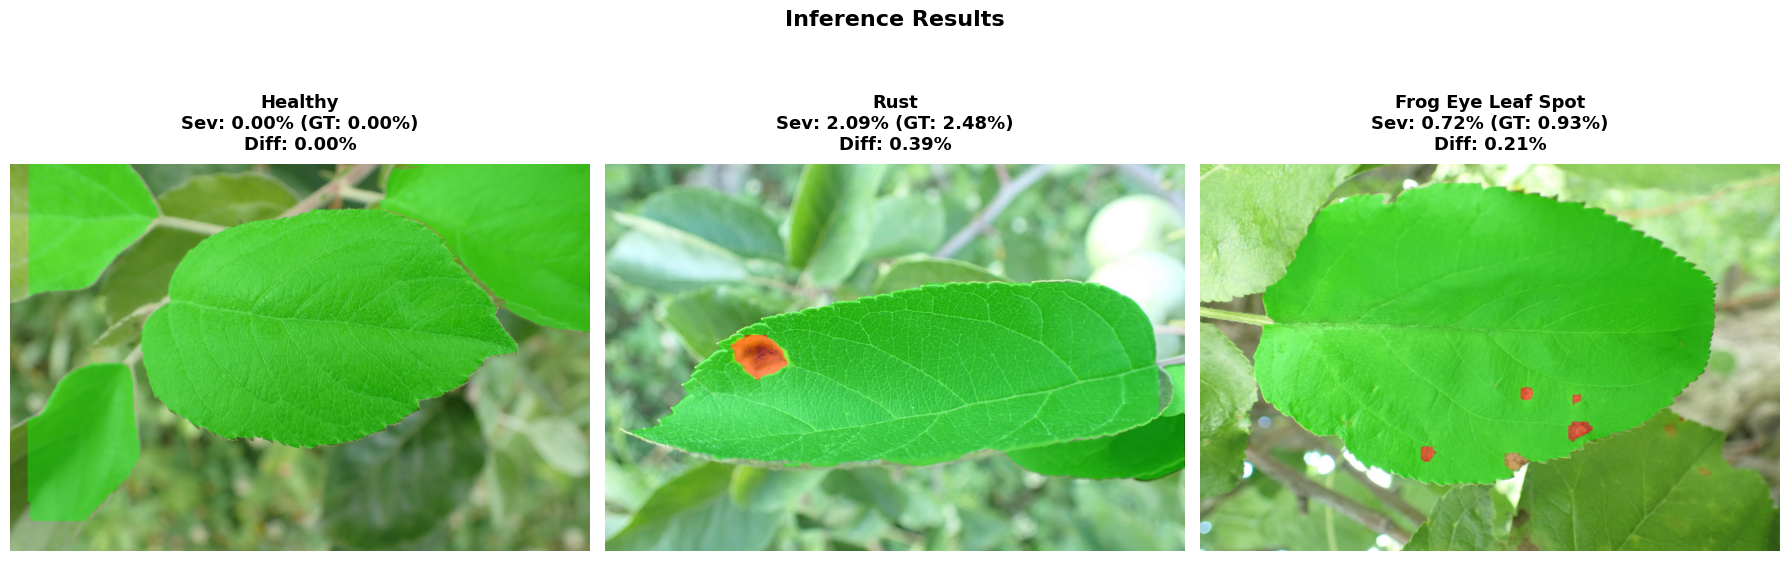

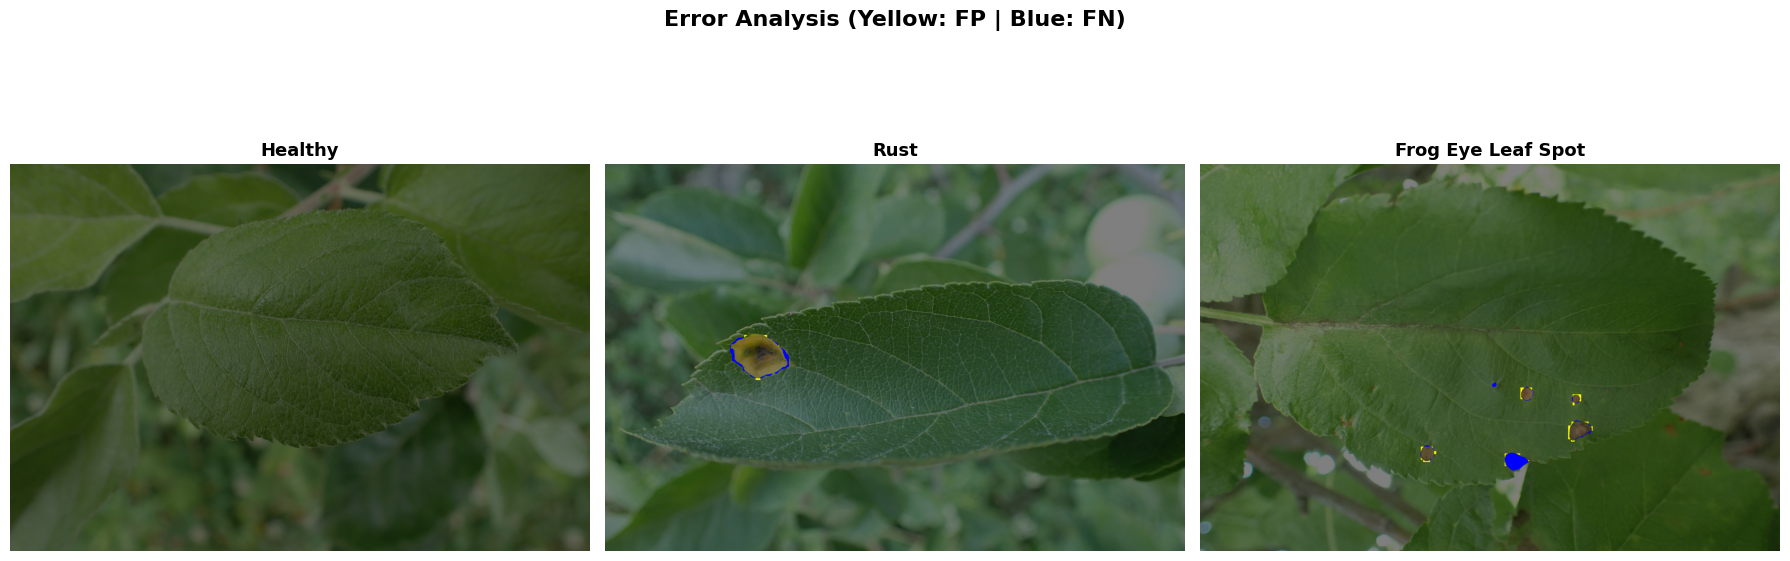

In [10]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path
import os

# --- 1. CONFIGURATION ---
SUBSET = 'test' 
# Pastikan path ini benar di sistem Anda
BASE_DATASET_PATH = Path("../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession")
IMAGE_DIR = BASE_DATASET_PATH / SUBSET / "images"
LABEL_DIR = BASE_DATASET_PATH / SUBSET / "labels" # Folder label YOLO (.txt)
GT_CSV_PATH = Path(f"../ground_truth_experiment/results/{SUBSET}/csv/severity_results_{SUBSET}.csv")

# Model Paths (Hanya MS-SM)
MODEL_OD_PATH = Path("best_model/object_detection/best.pt")
MODEL_SEG_SINGLE_PATH = Path("best_model/segmentation/single_module/leaf_and_lession.pt")

OUTPUT_DIR = Path("results/final_live_inference")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Classes Configuration
# Sesuaikan ID kelas ini dengan model segmentation Anda
LEAF_CLASSES = [0, 2, 3] 
LESION_CLASSES = [1, 4]
PADDING_RATIO = 0.3 

# --- 2. HELPER FUNCTIONS ---

def parse_percent(x):
    """Membersihkan string persen dari CSV"""
    if isinstance(x, str):
        return float(x.replace('%', '').strip())
    return float(x) if x is not None else 0.0

def load_gt_masks(filename, h, w):
    """
    Membaca file label YOLO (.txt) dan mengubahnya menjadi Binary Mask.
    Output: gt_leaf_mask, gt_lesion_mask
    """
    # Ganti ekstensi gambar ke .txt
    label_filename = Path(filename).stem + ".txt"
    label_path = LABEL_DIR / label_filename
    
    gt_leaf = np.zeros((h, w), dtype=np.uint8)
    gt_lesion = np.zeros((h, w), dtype=np.uint8)
    
    if not label_path.exists():
        print(f"[WARNING] Label file not found: {label_path}")
        return gt_leaf, gt_lesion

    with open(label_path, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = list(map(float, line.strip().split()))
        cls_id = int(parts[0])
        coords = parts[1:]
        
        # Denormalisasi koordinat YOLO (0-1) ke Piksel (0-w, 0-h)
        points = []
        for i in range(0, len(coords), 2):
            x = int(coords[i] * w)
            y = int(coords[i+1] * h)
            points.append([x, y])
        
        pts = np.array([points], dtype=np.int32)
        
        if cls_id in LEAF_CLASSES:
            cv2.fillPoly(gt_leaf, pts, 1)
        elif cls_id in LESION_CLASSES:
            cv2.fillPoly(gt_lesion, pts, 1)
            
    return gt_leaf, gt_lesion

def draw_overlay(img, leaf_mask, lesion_mask):
    """Visualisasi Plot 1: Overlay Hijau (Daun) dan Merah (Lesi)"""
    vis = img.copy()
    overlay = img.copy()
    
    # Warna RGB
    if leaf_mask is not None:
        overlay[leaf_mask == 1] = [0, 255, 0] # Hijau
    if lesion_mask is not None:
        overlay[lesion_mask == 1] = [255, 0, 0] # Merah
        
    return cv2.addWeighted(vis, 0.6, overlay, 0.4, 0)

def draw_error_map(img, gt_lesion_mask, pred_lesion_mask):
    """
    Visualisasi Plot 2 (Error Analysis):
    - False Positive (Pred=1, GT=0) -> Kuning Terang [255, 255, 0]
    - False Negative (Pred=0, GT=1) -> Biru Terang [0, 0, 255]
    """
    vis = img.copy()
    # Gelapkan background agar warna error mencolok
    vis = (vis * 0.5).astype(np.uint8) 
    
    # Hitung Mask Error
    fp_mask = cv2.bitwise_and(pred_lesion_mask, cv2.bitwise_not(gt_lesion_mask))
    fn_mask = cv2.bitwise_and(cv2.bitwise_not(pred_lesion_mask), gt_lesion_mask)
    
    # Apply Warna (Format RGB untuk Matplotlib)
    vis[fp_mask == 1] = [255, 255, 0] # Kuning
    vis[fn_mask == 1] = [0, 0, 255]   # Biru
    
    return vis

# --- 3. INFERENCE LOGIC (MS-SM Only) ---

def get_crop(img, model_od):
    """Deteksi objek dan return koordinat crop"""
    h, w = img.shape[:2]
    res_od = model_od(img, verbose=False, conf=0.25)[0]
    
    # Jika gagal deteksi, return full image
    if len(res_od.boxes) == 0: 
        return None, 0, 0, w, h
    
    # Ambil box terbesar
    areas = [(b[2]-b[0])*(b[3]-b[1]) for b in res_od.boxes.xyxy.cpu().numpy()]
    bx1, by1, bx2, by2 = res_od.boxes.xyxy.cpu().numpy()[np.argmax(areas)].astype(int)
    
    # Tambah Padding
    pad_x = int((bx2-bx1) * PADDING_RATIO)
    pad_y = int((by2-by1) * PADDING_RATIO)
    
    x1, y1 = max(0, bx1-pad_x), max(0, by1-pad_y)
    x2, y2 = min(w, bx2+pad_x), min(h, by2+pad_y)
    
    return img[y1:y2, x1:x2], x1, y1, x2, y2

def run_ms_sm_inference(img, model_od, model_seg):
    """
    Pipeline Multi-Stage Single-Module:
    1. Detect -> Crop
    2. Segment (Single Model) -> Pisahkan Leaf & Lesion berdasarkan Class ID
    3. Kembalikan ke ukuran asli untuk perbandingan GT
    """
    h_orig, w_orig = img.shape[:2]
    
    # 1. Crop
    crop_img, x1, y1, x2, y2 = get_crop(img, model_od)
    if crop_img is None: 
        return 0.0, np.zeros((h_orig, w_orig)), np.zeros((h_orig, w_orig))

    h_crop, w_crop = crop_img.shape[:2]
    
    # 2. Segmentation (Single Module)
    res = model_seg(crop_img, verbose=False, conf=0.1)[0]
    
    leaf_mask_crop = np.zeros((h_crop, w_crop), dtype=np.uint8)
    lesion_mask_crop = np.zeros((h_crop, w_crop), dtype=np.uint8)
    
    if res.masks is not None:
        polygons = res.masks.xy
        classes = res.boxes.cls.cpu().numpy()
        
        for poly, cls_id in zip(polygons, classes):
            if len(poly) > 0:
                pts = np.array([poly], dtype=np.int32)
                
                # Pisahkan berdasarkan Class ID
                if cls_id in LEAF_CLASSES:
                    cv2.fillPoly(leaf_mask_crop, pts, 1)
                elif cls_id in LESION_CLASSES:
                    cv2.fillPoly(lesion_mask_crop, pts, 1)

    # 3. Refinement: Lesion harus berada di dalam area Leaf
    lesion_mask_crop = cv2.bitwise_and(lesion_mask_crop, lesion_mask_crop, mask=leaf_mask_crop)
    
    # 4. Calculate Severity (pada crop)
    l_area = np.sum(leaf_mask_crop)
    s_area = np.sum(lesion_mask_crop)
    severity = (s_area / l_area * 100) if l_area > 0 else 0.0
    
    # 5. Restore ke Ukuran Asli (Un-Crop)
    final_leaf_mask = np.zeros((h_orig, w_orig), dtype=np.uint8)
    final_lesion_mask = np.zeros((h_orig, w_orig), dtype=np.uint8)
    
    final_leaf_mask[y1:y2, x1:x2] = leaf_mask_crop
    final_lesion_mask[y1:y2, x1:x2] = lesion_mask_crop
    
    return severity, final_leaf_mask, final_lesion_mask

# --- 4. MAIN EXECUTION ---

def main():
    print("--- Loading Models (Multi-Stage Single-Module) ---")
    model_od = YOLO(MODEL_OD_PATH)
    model_seg = YOLO(MODEL_SEG_SINGLE_PATH)
    
    # Load GT Data
    if not GT_CSV_PATH.exists():
        print(f"Error: CSV GT tidak ditemukan di {GT_CSV_PATH}")
        return

    gt_df = pd.read_csv(GT_CSV_PATH)
    gt_df['nama_file'] = gt_df['nama_file'].astype(str).str.strip()
    
    # Urutan Kategori yang diminta
    category_order = ["Healthy", "Rust", "Frog Eye Leaf Spot"]
    
    # Keyword pencarian file di CSV
    category_keywords = {
        "Healthy": "healthy",
        "Rust": "rust",
        "Frog Eye Leaf Spot": "frog_eye_leaf_spot"
    }
    
    # Ambil 1 sampel per kategori
    selected_samples = {}
    print("\n--- Selecting Samples ---")
    for cat in category_order:
        keyword = category_keywords[cat]
        candidates = gt_df[gt_df['nama_file'].str.contains(keyword, case=False)]
        
        if not candidates.empty:
            chosen = candidates.sample(1).iloc[0]
            selected_samples[cat] = chosen
            print(f"[{cat}] -> {chosen['nama_file']}")
        else:
            print(f"[WARNING] Tidak ada file ditemukan untuk kategori: {cat}")

    # Container Data
    results_data = {} 

    # --- PROCESS INFERENCE ---
    for cat in category_order:
        if cat not in selected_samples: continue
        
        item = selected_samples[cat]
        filename = item['nama_file']
        gt_sev_val = parse_percent(item['severity_estimation'])
        img_path = IMAGE_DIR / filename
        
        if not img_path.exists(): 
            print(f"File image tidak ditemukan: {img_path}")
            continue
            
        # Baca Image (RGB)
        orig_img = cv2.imread(str(img_path))
        orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
        h, w = orig_img_rgb.shape[:2]

        # 1. Run MS-SM Inference
        pred_sev, pred_leaf_m, pred_lesion_m = run_ms_sm_inference(orig_img_rgb, model_od, model_seg)
        
        # 2. Load GT Masks (YOLO Txt)
        gt_leaf_m, gt_lesion_m = load_gt_masks(filename, h, w)
        
        # 3. Create Visualizations
        # A. Plot 1: Visual Overlay
        vis_pred = draw_overlay(orig_img_rgb, pred_leaf_m, pred_lesion_m)
        
        # B. Plot 2: Error Analysis (FP/FN)
        vis_error = draw_error_map(orig_img_rgb, gt_lesion_m, pred_lesion_m)
        
        results_data[cat] = {
            'filename': filename,
            'vis_pred': vis_pred,
            'vis_error': vis_error,
            'pred_sev': pred_sev,
            'gt_sev': gt_sev_val,
            'diff': abs(pred_sev - gt_sev_val)
        }

    # --- PLOTTING ---
    if not results_data:
        print("Tidak ada data untuk di-plot.")
        return

    # === PLOT 1: VISUAL INFERENCE ===
    fig1, axes1 = plt.subplots(1, 3, figsize=(18, 6))
    if len(category_order) == 1: axes1 = [axes1] # Handle jika hanya 1 kategori
    
    # Judul global bisa dikosongkan jika mau bersih total, atau biarkan deskriptif
    fig1.suptitle("Inference Results", fontsize=16, fontweight='bold', y=1.05)
    
    for ax, cat in zip(axes1, category_order):
        if cat in results_data:
            data = results_data[cat]
            ax.imshow(data['vis_pred'])
            
            # Judul Sesuai Permintaan: Category, Sev, GT, Diff (Tanpa nama skema)
            title_txt = (f"{cat}\n"
                         f"Sev: {data['pred_sev']:.2f}% (GT: {data['gt_sev']:.2f}%)\n"
                         f"Diff: {data['diff']:.2f}%")
            
            ax.set_title(title_txt, fontsize=13, fontweight='bold', pad=10)
            ax.axis('off')
        else:
            ax.axis('off') # Kosong jika data tidak ada

    save_path1 = OUTPUT_DIR / "visual_inference_result.png"
    fig1.tight_layout()
    fig1.savefig(save_path1, bbox_inches='tight', dpi=150)
    print(f"\n[DONE] Plot 1 disimpan: {save_path1}")

    # === PLOT 2: ERROR ANALYSIS (FP/FN) ===
    fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))
    if len(category_order) == 1: axes2 = [axes2]
    
    fig2.suptitle("Error Analysis (Yellow: FP | Blue: FN)", fontsize=16, fontweight='bold', y=1.05)

    for ax, cat in zip(axes2, category_order):
        if cat in results_data:
            data = results_data[cat]
            ax.imshow(data['vis_error'])
            ax.set_title(f"{cat}", fontsize=13, fontweight='bold')
            ax.axis('off')
        else:
            ax.axis('off')

    save_path2 = OUTPUT_DIR / "error_analysis_result.png"
    fig2.tight_layout()
    fig2.savefig(save_path2, bbox_inches='tight', dpi=150)
    print(f"[DONE] Plot 2 disimpan: {save_path2}")

if __name__ == "__main__":
    main()

Loading Models...
Processing: ../dataset_collection/roboflow/object_detection/object_detection_rust/train/images/08983_rust_jpg.rf.253b8090c2a26525b6257441a897d8c5.jpg

[SUKSES] Alur penelitian disimpan di: results/final_paper_pipeline\pipeline_flow_08983_rust_jpg.rf.253b8090c2a26525b6257441a897d8c5.png


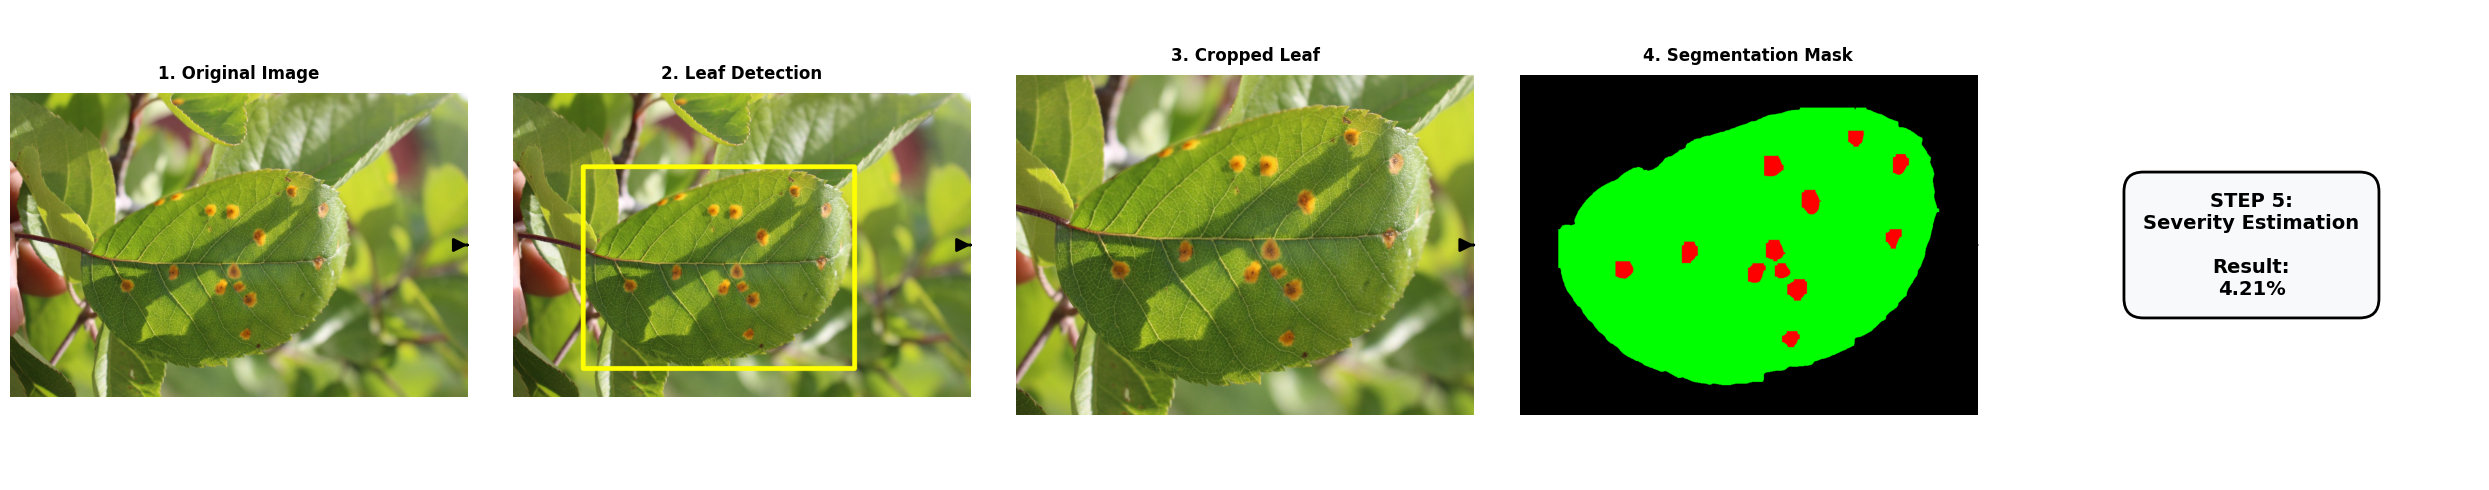

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from ultralytics import YOLO
from pathlib import Path
import os
import sys

# ==========================================
# 1. KONFIGURASI USER
# ==========================================

# A. INPUT GAMBAR (Ganti path ini sesuai file Anda)
INPUT_IMAGE_PATH = r"../dataset_collection/roboflow/object_detection/object_detection_rust/train/images/08983_rust_jpg.rf.253b8090c2a26525b6257441a897d8c5.jpg"

# B. OUTPUT FOLDER
OUTPUT_FOLDER = "results/final_paper_pipeline"

# C. PATH MODEL
MODEL_OD_PATH = "best_model/object_detection/best.pt"
MODEL_SEG_PATH = "best_model/segmentation/single_module/leaf_and_lession.pt"

# D. SETTING VISUAL
BOX_THICKNESS = 25        # Garis kotak deteksi tebal
PADDING_RATIO = 0.1       # Padding crop 10%
LEAF_CLASSES = [0, 2, 3]  
LESION_CLASSES = [1, 4]

# ==========================================

def get_best_box(res_od):
    if len(res_od.boxes) == 0: return None
    areas = [(b[2]-b[0])*(b[3]-b[1]) for b in res_od.boxes.xyxy.cpu().numpy()]
    best_idx = np.argmax(areas)
    return res_od.boxes.xyxy.cpu().numpy()[best_idx].astype(int)

def add_padding(bx1, by1, bx2, by2, w, h):
    pad_x = int((bx2-bx1) * PADDING_RATIO)
    pad_y = int((by2-by1) * PADDING_RATIO)
    x1 = max(0, bx1 - pad_x)
    y1 = max(0, by1 - pad_y)
    x2 = min(w, bx2 + pad_x)
    y2 = min(h, by2 + pad_y)
    return x1, y1, x2, y2

def run_pipeline(img_path, model_od, model_seg):
    # 1. Load Image
    if not os.path.exists(img_path):
        print(f"Error: Path salah {img_path}")
        sys.exit()
        
    orig_img = cv2.imread(img_path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    h, w = orig_img.shape[:2]
    
    # 2. Detection
    res_od = model_od(orig_img, verbose=False, conf=0.25)[0]
    img_detection = orig_img.copy()
    box = get_best_box(res_od)
    
    if box is not None:
        bx1, by1, bx2, by2 = box
        cv2.rectangle(img_detection, (bx1, by1), (bx2, by2), (255, 255, 0), BOX_THICKNESS)
        cx1, cy1, cx2, cy2 = add_padding(bx1, by1, bx2, by2, w, h)
    else:
        cx1, cy1, cx2, cy2 = 0, 0, w, h

    # 3. Crop
    img_crop = orig_img[cy1:cy2, cx1:cx2].copy()
    h_c, w_c = img_crop.shape[:2]

    # 4. Segmentation (Single Best Leaf)
    res_seg = model_seg(img_crop, verbose=False, conf=0.1)[0]
    img_segmentation = np.zeros((h_c, w_c, 3), dtype=np.uint8) # Hitam
    
    leaf_mask = np.zeros((h_c, w_c), dtype=np.uint8)
    lesion_mask = np.zeros((h_c, w_c), dtype=np.uint8)

    if res_seg.masks is not None:
        polygons = res_seg.masks.xy
        classes = res_seg.boxes.cls.cpu().numpy()
        
        # Cari daun terbesar
        leaf_polygons = []
        for poly, cls_id in zip(polygons, classes):
            if cls_id in LEAF_CLASSES and len(poly) > 0:
                pts = np.array([poly], dtype=np.int32)
                area = cv2.contourArea(pts)
                leaf_polygons.append((area, pts))
        
        if leaf_polygons:
            largest_leaf = sorted(leaf_polygons, key=lambda x: x[0], reverse=True)[0][1]
            cv2.fillPoly(leaf_mask, [largest_leaf], 1)
        
        # Ambil semua lesi
        for poly, cls_id in zip(polygons, classes):
            if cls_id in LESION_CLASSES and len(poly) > 0:
                pts = np.array([poly], dtype=np.int32)
                cv2.fillPoly(lesion_mask, pts, 1)
    
    # Apply Color
    img_segmentation[leaf_mask == 1] = [0, 255, 0] # Hijau
    lesion_in_leaf = cv2.bitwise_and(lesion_mask, lesion_mask, mask=leaf_mask)
    img_segmentation[lesion_in_leaf == 1] = [255, 0, 0] # Merah

    # 5. Calc Severity
    l_area = np.sum(leaf_mask)
    s_area = np.sum(lesion_in_leaf)
    severity = (s_area / l_area * 100) if l_area > 0 else 0.0

    return orig_img, img_detection, img_crop, img_segmentation, severity

def draw_arrow(ax_src, ax_dst):
    """Menggambar panah antar subplot"""
    xyA = (1.0, 0.5) 
    xyB = (-0.1, 0.5) 
    con = ConnectionPatch(xyA=xyA, xyB=xyB, 
                          coordsA="axes fraction", coordsB="axes fraction",
                          axesA=ax_src, axesB=ax_dst,
                          arrowstyle="-|>", color="black", linewidth=2,
                          mutation_scale=20)
    ax_src.add_artist(con)

def main():
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)
    
    # Load Models
    print("Loading Models...")
    model_od = YOLO(MODEL_OD_PATH)
    model_seg = YOLO(MODEL_SEG_PATH)

    # Run Pipeline
    print(f"Processing: {INPUT_IMAGE_PATH}")
    img_orig, img_det, img_crop, img_seg, sev = run_pipeline(INPUT_IMAGE_PATH, model_od, model_seg)
    
    # --- PLOTTING ---
    # Buat 5 Subplot (4 Gambar + 1 Teks)
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    
    # Definisi Konten untuk 4 Kolom Pertama
    images = [img_orig, img_det, img_crop, img_seg]
    titles = [
        "1. Original Image", 
        "2. Leaf Detection", 
        "3. Cropped Leaf", 
        "4. Segmentation Mask"
    ]
    
    # 1. Plot Gambar (Kolom 0-3)
    for i in range(4):
        ax = axes[i]
        ax.imshow(images[i])
        ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=10)
        ax.axis('off')
        
        # Gambar panah ke kanan (menuju ax berikutnya)
        draw_arrow(axes[i], axes[i+1])

    # 2. Plot Teks Severity (Kolom 4) -> Diperlakukan sebagai 'Plot'
    ax_text = axes[4]
    ax_text.axis('off') # Hilangkan border kotak
    ax_text.set_xlim(0, 1)
    ax_text.set_ylim(0, 1)
    
    # Teks Hasil
    result_text = f"STEP 5:\nSeverity Estimation\n\nResult:\n{sev:.2f}%"
    
    # Tampilkan teks di tengah subplot ke-5 dengan kotak styling
    ax_text.text(0.5, 0.5, result_text, 
                 fontsize=14, fontweight='bold', 
                 ha='center', va='center',
                 bbox=dict(boxstyle="round,pad=1.0", fc="#f8f9fa", ec="black", lw=2))

    plt.tight_layout()
    
    # Simpan
    filename = Path(INPUT_IMAGE_PATH).stem
    save_path = os.path.join(OUTPUT_FOLDER, f"pipeline_flow_{filename}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"\n[SUKSES] Alur penelitian disimpan di: {save_path}")
    plt.show()

if __name__ == "__main__":
    main()

In [ ]:
INPUT_IMAGE_PATH = r"../dataset_collection/roboflow/object_detection/object_detection_rust/train/images/08983_rust_jpg.rf.253b8090c2a26525b6257441a897d8c5.jpg"

Loading Models...
Processing: ../dataset_collection/roboflow/object_detection/object_detection_rust/train/images/08983_rust_jpg.rf.253b8090c2a26525b6257441a897d8c5.jpg
Menyimpan gambar per tahapan...
Membuat plot gabungan...

[SUKSES] Semua hasil disimpan di folder: results/final_paper_pipeline_separated


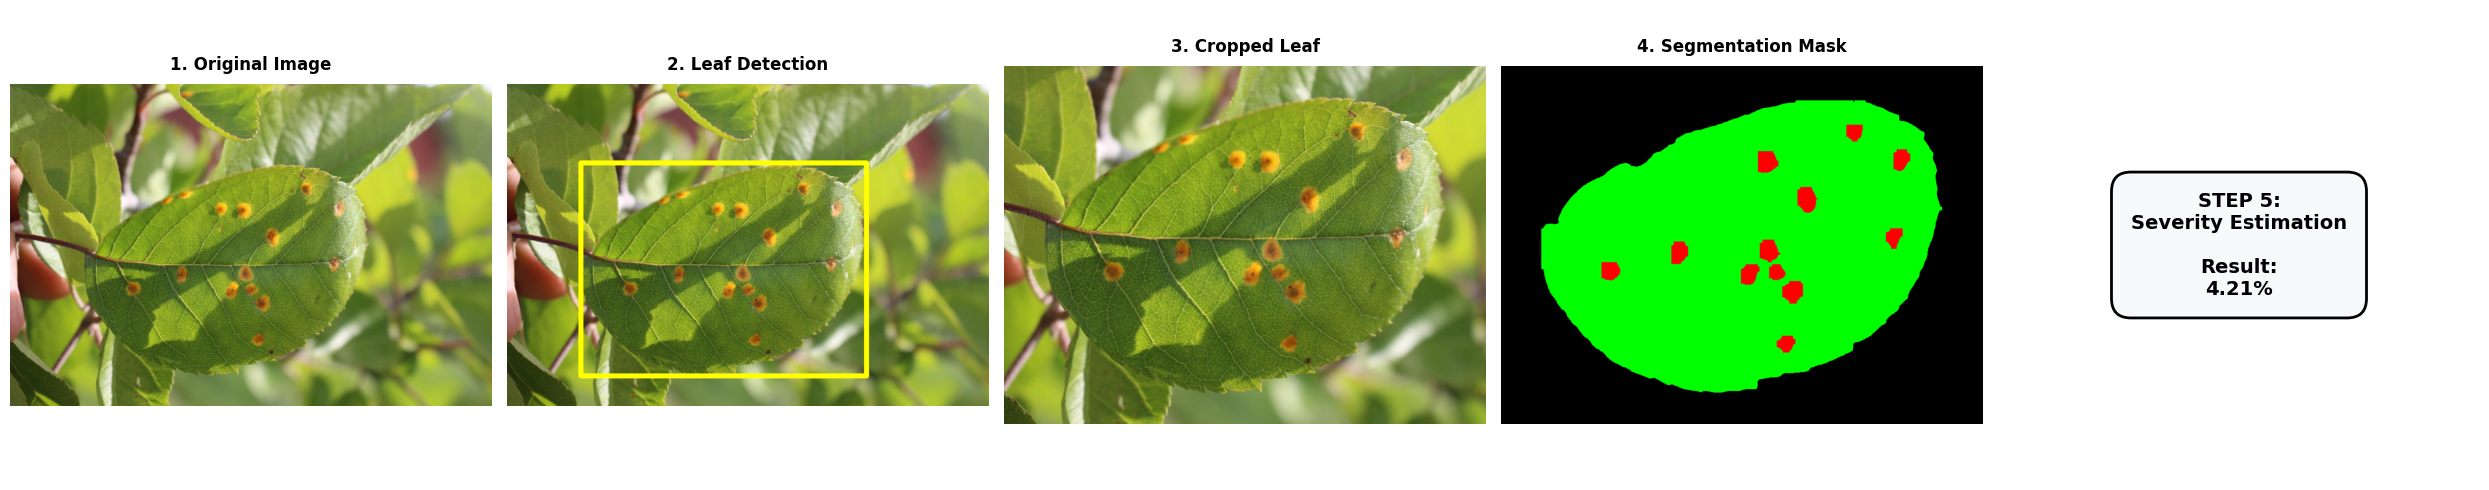

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# from matplotlib.patches import ConnectionPatch # <-- Dihapus karena tidak pakai panah
from ultralytics import YOLO
from pathlib import Path
import os
import sys

# ==========================================
# 1. KONFIGURASI USER
# ==========================================

# A. INPUT GAMBAR (Ganti path ini sesuai file Anda)
INPUT_IMAGE_PATH = r"../dataset_collection/roboflow/object_detection/object_detection_rust/train/images/08983_rust_jpg.rf.253b8090c2a26525b6257441a897d8c5.jpg"

# B. OUTPUT FOLDER
OUTPUT_FOLDER = "results/final_paper_pipeline_separated" # Saya ubah sedikit nama foldernya

# C. PATH MODEL
MODEL_OD_PATH = "best_model/object_detection/best.pt"
MODEL_SEG_PATH = "best_model/segmentation/single_module/leaf_and_lession.pt"

# D. SETTING VISUAL
BOX_THICKNESS = 25        # Garis kotak deteksi tebal
PADDING_RATIO = 0.1       # Padding crop 10%
LEAF_CLASSES = [0, 2, 3]  
LESION_CLASSES = [1, 4]

# ==========================================

def get_best_box(res_od):
    if len(res_od.boxes) == 0: return None
    areas = [(b[2]-b[0])*(b[3]-b[1]) for b in res_od.boxes.xyxy.cpu().numpy()]
    best_idx = np.argmax(areas)
    return res_od.boxes.xyxy.cpu().numpy()[best_idx].astype(int)

def add_padding(bx1, by1, bx2, by2, w, h):
    pad_x = int((bx2-bx1) * PADDING_RATIO)
    pad_y = int((by2-by1) * PADDING_RATIO)
    x1 = max(0, bx1 - pad_x)
    y1 = max(0, by1 - pad_y)
    x2 = min(w, bx2 + pad_x)
    y2 = min(h, by2 + pad_y)
    return x1, y1, x2, y2

def run_pipeline(img_path, model_od, model_seg):
    # 1. Load Image
    if not os.path.exists(img_path):
        print(f"Error: Path salah {img_path}")
        sys.exit()
        
    orig_img = cv2.imread(img_path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB) # Convert ke RGB untuk Matplotlib
    h, w = orig_img.shape[:2]
    
    # 2. Detection
    res_od = model_od(orig_img, verbose=False, conf=0.25)[0]
    img_detection = orig_img.copy()
    box = get_best_box(res_od)
    
    if box is not None:
        bx1, by1, bx2, by2 = box
        cv2.rectangle(img_detection, (bx1, by1), (bx2, by2), (255, 255, 0), BOX_THICKNESS)
        cx1, cy1, cx2, cy2 = add_padding(bx1, by1, bx2, by2, w, h)
    else:
        cx1, cy1, cx2, cy2 = 0, 0, w, h

    # 3. Crop
    img_crop = orig_img[cy1:cy2, cx1:cx2].copy()
    h_c, w_c = img_crop.shape[:2]

    # 4. Segmentation (Single Best Leaf)
    res_seg = model_seg(img_crop, verbose=False, conf=0.1)[0]
    img_segmentation = np.zeros((h_c, w_c, 3), dtype=np.uint8) # Hitam
    
    leaf_mask = np.zeros((h_c, w_c), dtype=np.uint8)
    lesion_mask = np.zeros((h_c, w_c), dtype=np.uint8)

    if res_seg.masks is not None:
        polygons = res_seg.masks.xy
        classes = res_seg.boxes.cls.cpu().numpy()
        
        # Cari daun terbesar
        leaf_polygons = []
        for poly, cls_id in zip(polygons, classes):
            if cls_id in LEAF_CLASSES and len(poly) > 0:
                pts = np.array([poly], dtype=np.int32)
                area = cv2.contourArea(pts)
                leaf_polygons.append((area, pts))
        
        if leaf_polygons:
            largest_leaf = sorted(leaf_polygons, key=lambda x: x[0], reverse=True)[0][1]
            cv2.fillPoly(leaf_mask, [largest_leaf], 1)
        
        # Ambil semua lesi
        for poly, cls_id in zip(polygons, classes):
            if cls_id in LESION_CLASSES and len(poly) > 0:
                pts = np.array([poly], dtype=np.int32)
                cv2.fillPoly(lesion_mask, pts, 1)
    
    # Apply Color
    img_segmentation[leaf_mask == 1] = [0, 255, 0] # Hijau
    lesion_in_leaf = cv2.bitwise_and(lesion_mask, lesion_mask, mask=leaf_mask)
    img_segmentation[lesion_in_leaf == 1] = [255, 0, 0] # Merah

    # 5. Calc Severity
    l_area = np.sum(leaf_mask)
    s_area = np.sum(lesion_in_leaf)
    severity = (s_area / l_area * 100) if l_area > 0 else 0.0

    return orig_img, img_detection, img_crop, img_segmentation, severity

# Fungsi draw_arrow DIHAPUS

def main():
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)
    
    # Load Models
    print("Loading Models...")
    model_od = YOLO(MODEL_OD_PATH)
    model_seg = YOLO(MODEL_SEG_PATH)

    # Run Pipeline
    print(f"Processing: {INPUT_IMAGE_PATH}")
    # Hasil return adalah format RGB
    img_orig_rgb, img_det_rgb, img_crop_rgb, img_seg_rgb, sev = run_pipeline(INPUT_IMAGE_PATH, model_od, model_seg)
    
    base_filename = Path(INPUT_IMAGE_PATH).stem

    # --- A. SIMPAN GAMBAR TERPISAH (INDIVIDUAL STAGES) ---
    print("Menyimpan gambar per tahapan...")
    # Penting: Convert kembali RGB ke BGR sebelum menyimpan dengan OpenCV
    cv2.imwrite(os.path.join(OUTPUT_FOLDER, f"{base_filename}_1_original.jpg"), cv2.cvtColor(img_orig_rgb, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(OUTPUT_FOLDER, f"{base_filename}_2_detection.jpg"), cv2.cvtColor(img_det_rgb, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(OUTPUT_FOLDER, f"{base_filename}_3_crop.jpg"), cv2.cvtColor(img_crop_rgb, cv2.COLOR_RGB2BGR))
    # Gunakan PNG untuk segmentasi agar warna solid tidak pecah (artifacts)
    cv2.imwrite(os.path.join(OUTPUT_FOLDER, f"{base_filename}_4_segmentation.png"), cv2.cvtColor(img_seg_rgb, cv2.COLOR_RGB2BGR))
    
    # --- B. PLOTTING GABUNGAN (TANPA PANAH) ---
    print("Membuat plot gabungan...")
    # Buat 5 Subplot (4 Gambar + 1 Teks)
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    
    # Definisi Konten untuk 4 Kolom Pertama (Gunakan yang RGB untuk Matplotlib)
    images = [img_orig_rgb, img_det_rgb, img_crop_rgb, img_seg_rgb]
    titles = [
        "1. Original Image", 
        "2. Leaf Detection", 
        "3. Cropped Leaf", 
        "4. Segmentation Mask"
    ]
    
    # 1. Plot Gambar (Kolom 0-3)
    for i in range(4):
        ax = axes[i]
        ax.imshow(images[i])
        ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=10)
        ax.axis('off')
        # TIDAK ADA draw_arrow DI SINI

    # 2. Plot Teks Severity (Kolom 4)
    ax_text = axes[4]
    ax_text.axis('off') 
    ax_text.set_xlim(0, 1)
    ax_text.set_ylim(0, 1)
    
    # Teks Hasil
    result_text = f"STEP 5:\nSeverity Estimation\n\nResult:\n{sev:.2f}%"
    
    ax_text.text(0.5, 0.5, result_text, 
                 fontsize=14, fontweight='bold', 
                 ha='center', va='center',
                 bbox=dict(boxstyle="round,pad=1.0", fc="#f8f9fa", ec="black", lw=2))

    plt.tight_layout()
    
    # Simpan Plot Gabungan
    save_path_combined = os.path.join(OUTPUT_FOLDER, f"{base_filename}_combined_flow_no_arrow.png")
    plt.savefig(save_path_combined, dpi=300, bbox_inches='tight')
    
    print(f"\n[SUKSES] Semua hasil disimpan di folder: {OUTPUT_FOLDER}")
    # plt.show() # Optional: komen ini jika tidak ingin menampilkan window plot

if __name__ == "__main__":
    main()